# Métricas y sus intervalos de confianza y Comparación estadística de modelos

# NOTA: este notebook será en gran parte igual a los vistos anteriormente. Simplemente se cambiará una parte de la etapa 5 de evaluación para incluir la creación de intervalos de confianza para las métricas y la Comparación estadística de modelos


# CRISP DM para un problema de machine learning supervisado de regresión

# Introducción al modelado

### con árboles de decisión

En este notebook, recorreremos las fases de CRISP-DM para resolver un problema de aprendizaje supervisado de regresión utilizando árboles de decisión.

El problema que vamos a resolver consiste en poder modelar el precio de un carro usado utilizando sus características.

Datos provienen de: https://www.kaggle.com/datasets/sidharth178/car-prices-dataset

![Image of car](https://storage.googleapis.com/kaggle-datasets-images/1479517/2444963/1aaa3760e7dd34a87af175482c1514ae/dataset-cover.jpg?t=2021-07-21-09-56-46)

##### Importaciones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
%matplotlib inline
from matplotlib.pylab import rcParams
from datetime import datetime
import warnings
plt.rcParams.update({'font.size': 14})
warnings.filterwarnings('ignore')


## 1. Entendimiento de negocio

Aquí, en un ejercicio completo (como el del taller), se deberían hacer las diversas tareas e ítems que corresponden al entendimiento del negocio.

Como este caso es un ejemplo introductorio, solamente incluiré la problemática.

La problemática a resolver es que se busca poder estimar el precio de un vehículo usando las distintas características que lo componen, para de esta forma poder asignar un precio justo a cada uno de ellos al momento de su venta.

Este problema corresponde entonces a un problema supervisado de regresión (aprender a predecir el precio de carros usando sus características), que es el tipo de problemas de machine learning que veremos en este curso.

Recordemos entonces que las demás actividades del entendimiento de negocio quedan como ejercicio sugerido (estas se tendrían que hacer en un proyecto real):
- Preguntas de negocio
- Limitaciones
- Riesgos
- Objetivos analíticos (métricas a usar, que se va a optimizar, etc)
- etc.


## 2. Entendimiento de datos




Procedamos entonces ahora con la fase de entendimiento de datos.

#### Nota:

En este ejemplo introductorio no se incluyó, pero un problema real, sería muy bueno al inicio de esta etapa incluir el Diccionario de datos o de variables, para poder concoer muy bien nuestro conjunto de datos qué tiene y cuál es la descripción y contenido de cada una de las columnas.

### Carga de datos

Procedamos entonces primero a cargar los datos (asumiendo que ya entendemos bien la descricpión del conjunto y de sus columnas, lo cuál se vería en el diccionario de datos).

In [2]:
data_raw=pd.read_csv('CarPrices.csv')
data_raw.shape

(19225, 17)

### Análisis descriptivo

Ahora procedamos con el análisis descriptivo para entender mejor los datos.

Miremos ahora primero la información del conjunto de datos para ver un poco la descripción del dataframe.

In [3]:
data_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19225 entries, 0 to 19224
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19225 non-null  int64  
 1   Price             19225 non-null  int64  
 2   Manufacturer      19225 non-null  object 
 3   Model             19225 non-null  object 
 4   Prod. year        19225 non-null  int64  
 5   Category          19225 non-null  object 
 6   Leather interior  19225 non-null  object 
 7   Fuel type         19225 non-null  object 
 8   Engine volume     19225 non-null  object 
 9   Mileage           19225 non-null  object 
 10  Cylinders         19225 non-null  float64
 11  Gear box type     19225 non-null  object 
 12  Drive wheels      19225 non-null  object 
 13  Doors             19225 non-null  object 
 14  Wheel             19225 non-null  object 
 15  Color             19225 non-null  object 
 16  Airbags           19225 non-null  int64 

El info nos muestra los tipos de las columnas. Nos sirve por ejemplo para ver que hay muchas variables que se están leyendo como object (String) cuándo esperaríamos que fueran numéricas: Mileage (Millas totales), Doors (Puertas), etc, lo que indica posibles problemas de formato.

Miremos ahora el head y el tail.

In [4]:
data_raw.head(10)

,ID,Price,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
5,45802912,39493,HYUNDAI,Santa FE,2016,Jeep,Yes,Diesel,2,160931 km,4.0,Automatic,Front,04-May,Left wheel,White,4
6,45656768,1803,TOYOTA,Prius,2010,Hatchback,Yes,Hybrid,1.8,258909 km,4.0,Automatic,Front,04-May,Left wheel,White,12
7,45816158,549,HYUNDAI,Sonata,2013,Sedan,Yes,Petrol,2.4,216118 km,4.0,Automatic,Front,04-May,Left wheel,Grey,12
8,45641395,1098,TOYOTA,Camry,2014,Sedan,Yes,Hybrid,2.5,398069 km,4.0,Automatic,Front,04-May,Left wheel,Black,12
9,45756839,26657,LEXUS,RX 350,2007,Jeep,Yes,Petrol,3.5,128500 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12


In [5]:
data_raw.tail(10)

,ID,Price,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
19215,45763841,470,HYUNDAI,Elantra,2017,Sedan,Yes,Petrol,1.6,25635 km,4.0,Automatic,Front,04-May,Left wheel,Black,12
19216,45784464,37633,TOYOTA,RAV 4,2017,Jeep,Yes,Petrol,2.5,23430 km,4.0,Tiptronic,Front,04-May,Left wheel,Beige,12
19217,45804344,26017,LEXUS,ES 300,2009,Sedan,Yes,Petrol,3.5,132700 km,4.0,Automatic,Front,04-May,Left wheel,White,4
19218,45748699,30,NISSAN,Note,2006,Hatchback,No,Petrol,1.3,0 km,4.0,Automatic,Front,04-May,Right-hand drive,Green,9
19219,45789241,19444,TOYOTA,Prius,2013,Sedan,No,Hybrid,1.8,140607 km,4.0,Automatic,Front,04-May,Left wheel,Grey,12
19220,45795511,8467,MITSUBISHI,Outlander,2004,Universal,No,CNG,2.4,140000 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,6
19221,45776906,15681,VOLKSWAGEN,Jetta,2013,Sedan,Yes,Petrol,2.5,81200 km,5.0,Manual,Front,04-May,Left wheel,Silver,12
19222,45732720,10036,HYUNDAI,Sonata,2014,Sedan,Yes,LPG,2,735970 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
19223,44571028,8781,DODGE,Caliber,2008,Hatchback,No,Petrol,2.4,0 km,4.0,Automatic,Front,04-May,Left wheel,Blue,4
19224,45768089,19130,KIA,Optima ex,2014,Sedan,Yes,Petrol,2.4,35800 km,4.0,Automatic,Front,04-May,Left wheel,Black,12


Del head y tail se ven algunas cosas interesantes, como por ejemplo:

- Pareciera que los Hyundai tienen precios más altos que los demás.
- Hay algunas columnas con problemas de conformidad (ejemplo la de Doors (puertas) pareciera una fecha).
- En general pareciera que la mayoría de los carros tienen modelos cercanos a 2010 salvo por algunas excepciones.
- La mayor parte de los carros parecen ser automáticos (algo común en Estados Unidos).
- Hay un par de autos con precios excesivamente bajos, por ejemplo uno de ellos tiene un precio de solo 50 dólares. Se debe revisar con el equipo de negocio que puede pasar en estos porque pueden que se estén vendiendo como chatarra.
- Hay un par de variables que según nuestro conocimiento de negocio posiblemente no afecten tanto en el precio (cómo el color del carro y sobre todo su ID).

Por último en la parte de análisis descriptivo, miremos el describe.

In [6]:
data_raw.describe(include="all")

,ID,Price,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
count,1.922500e+04,1.922500e+04,19225,19225,19225.000000,19225,19225,19225,19225,19225,19225.000000,19225,19225,19225,19225,19225,19225.000000
unique,NaN,NaN,65,1590,NaN,11,2,7,107,7685,NaN,4,3,3,2,16,NaN
top,NaN,NaN,HYUNDAI,Prius,NaN,Sedan,Yes,Petrol,2,0 km,NaN,Automatic,Front,04-May,Left wheel,Black,NaN
freq,NaN,NaN,3766,1081,NaN,8730,13944,10148,3914,721,NaN,13506,12867,18321,17742,5030,NaN
mean,4.557671e+07,1.856181e+04,NaN,NaN,2010.914278,NaN,NaN,NaN,NaN,NaN,4.582939,NaN,NaN,NaN,NaN,NaN,6.582003
std,9.359993e+05,1.906404e+05,NaN,NaN,5.669212,NaN,NaN,NaN,NaN,NaN,1.200075,NaN,NaN,NaN,NaN,NaN,4.320223
min,2.074688e+07,1.000000e+00,NaN,NaN,1939.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000
25%,4.569830e+07,5.331000e+03,NaN,NaN,2009.000000,NaN,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,4.000000
50%,4.577228e+07,1.317200e+04,NaN,NaN,2012.000000,NaN,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,6.000000
75%,4.580204e+07,2.210600e+04,NaN,NaN,2015.000000,NaN,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,12.000000


#### Ejercicio:
Analice los patrones interesantes que se vean en el describe.

### Sobre las dimensiones de calidad de datos
Tener en cuenta que aquí procederíamos a mirar ahora una por una las dimensiones de calidad de datos, pero en este ejemplo introductorio no entraremos tan a detalle. Queda entonces como ejercicio sugerido mirar una por una las dimensiones de calidad de datos. 

Solo recordaremos por ahora los detalles interesantes a corregir que mencionamos anteriormente, como por ejemplo los autos que parecen venderse como chatarra y que algunas variables tienen un formato inesperado (como por ejemplo la de Mileage).

Así, por ahora solo haremos hasta aquí el entendimiento de datos, pero en un problema real se recuerda que se debe hacer mucho más a detalle con las demás etapas vistas en clase.

## 3. Preparación de datos

### Selección del conjunto de datos a usar


#### Tratamiento de outliers muy evidentes (precio)

En este caso, para el ejercicio me enfocaré solamente en los carros con valores de al menos mil dólares. Esto es debido a que hay varios de ellos con valores de menos de mil dólares, pero es muy raro que un carro cueste eso por lo que puede ser algún error de los datos o que se estén vendiendo como chatarra, lo cuál no es algo que querré incluir en mi análisis 

(Notar que al hacer este descarte, debo confirmar que el equipo de negocio esté de acuerdo. Por ejemplo, si ellos me dijeran que sí les interesan estos carros de menos de mil dólares así sean chatarra, no podría quitar las filas de estos).

In [7]:
data_filtered = data_raw[data_raw["Price"]>=1000]
data_filtered

,ID,Price,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19220,45795511,8467,MITSUBISHI,Outlander,2004,Universal,No,CNG,2.4,140000 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,6
19221,45776906,15681,VOLKSWAGEN,Jetta,2013,Sedan,Yes,Petrol,2.5,81200 km,5.0,Manual,Front,04-May,Left wheel,Silver,12
19222,45732720,10036,HYUNDAI,Sonata,2014,Sedan,Yes,LPG,2,735970 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
19223,44571028,8781,DODGE,Caliber,2008,Hatchback,No,Petrol,2.4,0 km,4.0,Automatic,Front,04-May,Left wheel,Blue,4


##### Cuidado

Actualmente, el valor promedio de los precios de los vehículos es

In [8]:
# Valor promedio de los precios de los vehiculos
data_filtered["Price"].mean()

21361.078234764336

Sin embargo, del describe se debió haber notado un valor extremadamente alto en el precio máximo (un carro con precio de 26.7 millones de dólares).
Miremos los carros ordenados por precio a ver si pasó algo raro:

In [9]:
data_filtered.sort_values(by="Price", ascending=False).head(10)

,ID,Price,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
16983,45812886,26307500,OPEL,Combo,1999,Goods wagon,No,Diesel,1.7,99999 km,4.0,Manual,Front,02-Mar,Left wheel,Blue,0
8541,45761204,872946,LAMBORGHINI,Urus,2019,Universal,Yes,Petrol,4,2531 km,8.0,Tiptronic,4x4,04-May,Left wheel,Black,0
1225,45795524,627220,MERCEDES-BENZ,G 65 AMG 63AMG,2020,Jeep,Yes,Petrol,6.3 Turbo,0 km,8.0,Tiptronic,4x4,04-May,Left wheel,Black,12
5008,45810285,308906,PORSCHE,911,2016,Coupe,Yes,Petrol,4,8690 km,6.0,Automatic,Rear,02-Mar,Left wheel,Black,12
9367,45229113,297930,MERCEDES-BENZ,AMG GT S,2015,Coupe,Yes,Petrol,4.0 Turbo,20000 km,8.0,Tiptronic,Rear,02-Mar,Left wheel,White,16
14839,45792307,297930,LAND ROVER,Range Rover Vogue,2019,Jeep,Yes,Diesel,3.0 Turbo,4500 km,8.0,Tiptronic,4x4,04-May,Left wheel,Black,12
7749,45760644,288521,BMW,M5 Машина в максимально,2018,Sedan,Yes,Petrol,4.4,13500 km,8.0,Tiptronic,4x4,04-May,Left wheel,Black,0
10759,45291161,260296,LEXUS,LX 570,2018,Jeep,Yes,Petrol,5.7 Turbo,17700 km,8.0,Tiptronic,4x4,04-May,Left wheel,Black,10
5840,44991441,254024,MERCEDES-BENZ,GLE 400 A M G,2016,Jeep,Yes,Petrol,3.0 Turbo,73000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,12
15283,45069516,250574,MERCEDES-BENZ,GLE 400,2017,Jeep,Yes,Petrol,3.0 Turbo,81600 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,12


Claramente, ese primer carro OPEL está demasiado raro, porque es un auto de 1999 que vale 26.7 millones de dólares. 

Conservar ese carro en nuestro dataset dañaría todos los modelos, por lo que lo voy a quitar (si quieren, en otra ocasión prueben como tarea sugerida que pasaría si no hubieran quitado este único dato, y verán que más adelante todos los modelos dan extremadamente diferentes en sus métricas puesto que se enfocarían mucho en ese único carro).

El segundo carro más costoso vale 800mil dólares, lo cual es un valor alto pero razonable teniendo en cuenta que es un lamborghini.

In [10]:
# Quitar auto de mas de 20 millones de 
data_filtered = data_filtered[data_filtered["Price"]<20000000]
data_filtered

,ID,Price,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19220,45795511,8467,MITSUBISHI,Outlander,2004,Universal,No,CNG,2.4,140000 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,6
19221,45776906,15681,VOLKSWAGEN,Jetta,2013,Sedan,Yes,Petrol,2.5,81200 km,5.0,Manual,Front,04-May,Left wheel,Silver,12
19222,45732720,10036,HYUNDAI,Sonata,2014,Sedan,Yes,LPG,2,735970 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
19223,44571028,8781,DODGE,Caliber,2008,Hatchback,No,Petrol,2.4,0 km,4.0,Automatic,Front,04-May,Left wheel,Blue,4


In [11]:
max(data_filtered["Price"])

872946

Para evitar problemas a futuro, luego de los filtrados reseteo el index:


In [12]:
# Tambien reseteo el index para evitar problemas a futuro
data_filtered = data_filtered.reset_index(drop=True)
data_filtered


,ID,Price,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16649,45795511,8467,MITSUBISHI,Outlander,2004,Universal,No,CNG,2.4,140000 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,6
16650,45776906,15681,VOLKSWAGEN,Jetta,2013,Sedan,Yes,Petrol,2.5,81200 km,5.0,Manual,Front,04-May,Left wheel,Silver,12
16651,45732720,10036,HYUNDAI,Sonata,2014,Sedan,Yes,LPG,2,735970 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
16652,44571028,8781,DODGE,Caliber,2008,Hatchback,No,Petrol,2.4,0 km,4.0,Automatic,Front,04-May,Left wheel,Blue,4


Observen como cambia ahora el valor promedio de los precios de los vehículos. 

In [13]:
# Valor promedio de los precios de los vehiculos
data_filtered["Price"].mean()

19782.71033985829

Un único valor outlier cambió 1600 dólares el precio promedio del total del conjunto total de 16 mil carros!!! 

Esto es prácticamente un cambio del 10% en el valor promedio de todos los carros, lo cuál es un cambio muy grande para una empresa (piensen que pasaría si a una empresa le decimos de repente que sus ventas estaban "mal calculadas" y en realidad son 10% menos de lo que se pensada... esto puede representar una diferencia de varios millones de dólares en su presupuesto!).

Y tengan en cuenta entonces que, de la misma forma que este dato afectó muchísimo la media, afectaría también muchísimos los modelos de machine learning que creemos, puesto que muchos de ellos para entrenarse usan métodos que se verían muy afectados por este valor (como por ejemplo el error cuadrático medio). 

Recuerden por ejemplo como en una regresión lineal la recta de regresión se puede desviar muy notablemente por culpa de un solo valor outlier: esto mismo pasaría en gran parte de los demás modelos de machine learning. (Link: https://www.google.com/search?client=firefox-b-d&sca_esv=566149086&q=linear+regression+with+an+outlier&tbm=isch&source=lnms&sa=X&ved=2ahUKEwjm28XFhrOBAxXjlWoFHWaYB0IQ0pQJegQIDRAB&biw=1366&bih=615&dpr=1#imgrc=zG2A1fmcPTyJGM)

Así, Se nota aquí el efecto tan catastrófico que puede tener un solo outlier en el conjunto de datos

### Seleccionar variables de interés

Por ahora, vamos a empezar por seleccionar solo algunas de las columnas de nuestro conjunto de datos. 

Ya sabíamos que hay algunas que posiblemente no sean tan importantes por lo que podemos pensar en omitirlas (color, ID, etc.).

Además, sabemos que hay muchas otras que necesitan preparaciones adicionales para poderse usar (ejemplo el Mileage que no venía numérico).

Así, para empezar con nuestras variables elegidas, por ahora tomemos solamente las que ya estaban listas para usar, que serían:

In [14]:
data_elegida = data_filtered[["Price", "Cylinders", "Airbags", "Prod. year"]]
data_elegida.head()

,Price,Cylinders,Airbags,Prod. year
0,13328,6.0,12,2010
1,16621,6.0,8,2011
2,8467,4.0,2,2006
3,3607,4.0,0,2011
4,11726,4.0,4,2014


### Preparación y selección de características a usar

Entremos ahora a hacer todas las preparaciones y correcciones necesarias para poder usar las demás columnas de interés en nuestro conjunto de datos. Recordemos que los modelos necesitan que las variables sean numéricas para poderlas usar.

##### Corrección de formatos:
Convertir primero la columna de mileage a algo útil (quitar el km) y que sea numerica.
Y agregar dicha variable al conjunto de datos.

In [15]:
# Columna antigua de Mileage
mileage = data_filtered["Mileage"]

# Quitar el " km"
kilometraje = mileage.str.replace(" km", "")

# Volverla numerica y pegarla a las variables elegidas
data_elegida["Kilometraje"] = pd.to_numeric(kilometraje)
data_elegida.head()

,Price,Cylinders,Airbags,Prod. year,Kilometraje
0,13328,6.0,12,2010,186005
1,16621,6.0,8,2011,192000
2,8467,4.0,2,2006,200000
3,3607,4.0,0,2011,168966
4,11726,4.0,4,2014,91901


#### Label encoding para variables categóricas:

Recordar que nuestros modelos usualmente no podrán procesar por defeto variables categóricas (Strings), ya que están diseñados para trabajar con variables numéricas.

Por ende, hay que hacer una preapración a estas variables para poderlas usar, la cual se llama "label encoding". El label encoding convierte las variables categóricas en variables numéricas que el modelo ya sí podrá utilizar.

Hay muchos tipos de label encoding, pero aquí solo usaremos los dos principales según el caso:

- Cuando las variables son nominales (no importa el orden), se debe usar one-hot encoding. Este crea una nueva columna binaria en 0 o 1 por cada categoría de la columna. Es recomendada cuando las categorías no tienen un orden (ejemplo: azul, verde, rojo, negro, amarillo).

- Cuando las variables son ordinales (sí importa el orden), se debe usar ordinal encoding. Este crea una sola nueva columna para todo el conjunto, en donde asigna un número de 0 a n a cada una de las categorías según su orden. Es recomendada cuando las categorías sí tienen un orden (ejemplo: deficiente, malo, regular, bueno, excelente).


Apliquemos entonces ahora encoding a la categoría "drive wheels", que indica en cuáles llantas tienen tracción los carros (delanteras, traseras o en todas).

Cómo esta columna no tiene un orden claro, aplicamos one-hot encoding.

In [16]:
onehot_wheels = pd.get_dummies(data_filtered["Drive wheels"])
data_elegida = data_elegida.join(onehot_wheels)
data_elegida.head()

,Price,Cylinders,Airbags,Prod. year,Kilometraje,4x4,Front,Rear
0,13328,6.0,12,2010,186005,1,0,0
1,16621,6.0,8,2011,192000,1,0,0
2,8467,4.0,2,2006,200000,0,1,0
3,3607,4.0,0,2011,168966,1,0,0
4,11726,4.0,4,2014,91901,0,1,0


Ahora, usando label encoding, preparemos la variable "Doors" para que también la podamos usar en el modelo. Esta variable indica el número de puertas posibles que puede tener un carro (2, 4 o más de 5). Tener en cuenta que aquí sí se puede considerar un orden en estas 3 categorías, por lo que se debe usar Ordinal Encoding. Recordar agregarla al conjunto a usar.

In [17]:
from sklearn.preprocessing import OrdinalEncoder

# Columna de doors antigua
doorsdf = data_filtered[["Doors"]]

# Defino la jerarquía u orden de las categorías, de menor a mayor
# (el número que se le asignará a cada uno dependerá de esto: 0 al primer elemento, 1 al segundo, etc...)
orden = ['02-Mar','04-May','>5']

# Crear el encoder

enc = OrdinalEncoder(categories=[orden])

# Aplicar el encoding
doorsnew = enc.fit_transform(doorsdf)

# Pegar la columna al dataframe de elegidas
data_elegida["Puertas"] = pd.DataFrame(doorsnew)
data_elegida.head()


,Price,Cylinders,Airbags,Prod. year,Kilometraje,4x4,Front,Rear,Puertas
0,13328,6.0,12,2010,186005,1,0,0,1.0
1,16621,6.0,8,2011,192000,1,0,0,1.0
2,8467,4.0,2,2006,200000,0,1,0,1.0
3,3607,4.0,0,2011,168966,1,0,0,1.0
4,11726,4.0,4,2014,91901,0,1,0,1.0


(Ojo: aquí la columna "Puertas" tendría un valor de 0 si tiene 2 puertas, 1 si tiene 4 puertas y 2 si tiene 5 o más puertas).

##### Validemos como va todo hasta aquí

Para validar que todo va bien hasta acá, comparemos algunas filas del dataset antes y después de la preparación de características.


In [18]:
data_filtered.head(10)

,ID,Price,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
5,45802912,39493,HYUNDAI,Santa FE,2016,Jeep,Yes,Diesel,2,160931 km,4.0,Automatic,Front,04-May,Left wheel,White,4
6,45656768,1803,TOYOTA,Prius,2010,Hatchback,Yes,Hybrid,1.8,258909 km,4.0,Automatic,Front,04-May,Left wheel,White,12
7,45641395,1098,TOYOTA,Camry,2014,Sedan,Yes,Hybrid,2.5,398069 km,4.0,Automatic,Front,04-May,Left wheel,Black,12
8,45756839,26657,LEXUS,RX 350,2007,Jeep,Yes,Petrol,3.5,128500 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
9,45814819,8781,FORD,Transit,1999,Microbus,No,CNG,4,0 km,8.0,Manual,Rear,02-Mar,Left wheel,Blue,0


In [19]:
data_elegida.head(10)

,Price,Cylinders,Airbags,Prod. year,Kilometraje,4x4,Front,Rear,Puertas
0,13328,6.0,12,2010,186005,1,0,0,1.0
1,16621,6.0,8,2011,192000,1,0,0,1.0
2,8467,4.0,2,2006,200000,0,1,0,1.0
3,3607,4.0,0,2011,168966,1,0,0,1.0
4,11726,4.0,4,2014,91901,0,1,0,1.0
5,39493,4.0,4,2016,160931,0,1,0,1.0
6,1803,4.0,12,2010,258909,0,1,0,1.0
7,1098,4.0,12,2014,398069,0,1,0,1.0
8,26657,6.0,12,2007,128500,1,0,0,1.0
9,8781,8.0,0,1999,0,0,0,1,0.0


In [20]:
data_filtered.tail()

,ID,Price,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
16649,45795511,8467,MITSUBISHI,Outlander,2004,Universal,No,CNG,2.4,140000 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,6
16650,45776906,15681,VOLKSWAGEN,Jetta,2013,Sedan,Yes,Petrol,2.5,81200 km,5.0,Manual,Front,04-May,Left wheel,Silver,12
16651,45732720,10036,HYUNDAI,Sonata,2014,Sedan,Yes,LPG,2,735970 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
16652,44571028,8781,DODGE,Caliber,2008,Hatchback,No,Petrol,2.4,0 km,4.0,Automatic,Front,04-May,Left wheel,Blue,4
16653,45768089,19130,KIA,Optima ex,2014,Sedan,Yes,Petrol,2.4,35800 km,4.0,Automatic,Front,04-May,Left wheel,Black,12


In [21]:
data_elegida.tail()

,Price,Cylinders,Airbags,Prod. year,Kilometraje,4x4,Front,Rear,Puertas
16649,8467,6.0,6,2004,140000,1,0,0,1.0
16650,15681,5.0,12,2013,81200,0,1,0,1.0
16651,10036,4.0,4,2014,735970,0,1,0,1.0
16652,8781,4.0,4,2008,0,0,1,0,1.0
16653,19130,4.0,12,2014,35800,0,1,0,1.0


In [22]:
len(data_filtered)

16654

In [23]:
len(data_elegida)

16654

Vemos entonces que por ahora parece ir todo bien con nuestra preparación de datos.

#### Ejercicio: 

Con la nueva variable llamada "data_elegida_copia", resuelva los siguientes puntos (NO modifique "data_elegida" para que no haya inconsistencias con el resto del notebook). 


In [24]:
data_elegida_copia = data_elegida.copy()

Ahora, resuelva:

1. Preparar la variable "Engine_volume" para que también la podamos usar en el modelo (dejaremos solo el valor numérico que ahí se presenta, que representa los litros que tiene el motor). Recordar agregarla al conjunto (data_elegida_copia).

2. Preparar las variable "Leather interior" para que también la podamos usar en el modelo (esta indica sí el interior del carro tiene cojinería de cuero o no). Recordar agregarla al conjunto (data_elegida_copia).

3. Preparar la variable "Fuel type" para que la podamos incluir en el modelo (esta variable indica el tipo de combustible que usa el vehículo). Recordar agregarla al conjunto (data_elegida_copia).

4. Muestre el "head" del conjunto de datos "data_elegida_copia" luego de preparar las 3 nuevas variables. ¿Sí quedó bien preparado?

### Un primer vistazo a la importancia de las variables

Aquí también es un buen momento para determinar cuáles variables pueden se realmente importantes para modelar esta problemática.

Esto ya se debió haber hecho desde el conocimiento del negocio; sin embargo, se puede realizar también con métodos estadísticos.

Como una guia inicial, miremos como queda la matriz de correlación lineal de los datos que tenemos hasta ahora (podemos calcular directamente la matriz de correlación al tener solo datos numéricos en nuestra data preparada, aunque hay que ser cuidadosos con su análisis).



In [25]:
data_elegida.corr()

,Price,Cylinders,Airbags,Prod. year,Kilometraje,4x4,Front,Rear,Puertas
Price,1.000000,0.166594,0.028887,0.329300,-0.017125,0.124247,-0.096772,-0.011633,0.032507
Cylinders,0.166594,1.000000,0.203453,-0.111540,-0.003432,0.444754,-0.554333,0.251285,-0.032440
Airbags,0.028887,0.203453,1.000000,0.239392,-0.007138,0.097887,-0.126674,0.061884,0.053443
Prod. year,0.329300,-0.111540,0.239392,1.000000,-0.063707,-0.083671,0.293860,-0.314344,0.186107
Kilometraje,-0.017125,-0.003432,-0.007138,-0.063707,1.000000,0.006136,-0.014374,0.012942,-0.007072
4x4,0.124247,0.444754,0.097887,-0.083671,0.006136,1.000000,-0.716124,-0.182018,0.030023
Front,-0.096772,-0.554333,-0.126674,0.293860,-0.014374,-0.716124,1.000000,-0.555966,0.112430
Rear,-0.011633,0.251285,0.061884,-0.314344,0.012942,-0.182018,-0.555966,1.000000,-0.194144
Puertas,0.032507,-0.032440,0.053443,0.186107,-0.007072,0.030023,0.112430,-0.194144,1.000000


Se observa algunas variables que ya vemos que nos podrán ser útiles para modelar el precio (sobre todo la de Production Year, que tiene la mayor correlación con el precio). Se observan aquí ya algunas relaciones esperadas: mientras más reciente el carro, más cuesta; a mayor número de cilindros, mayor el costo; los carros de 4x4 suelen costar más que los que no son 4x4, etc.

Es por ejemplo curioso también que el kilometraje parece no afectar casi (a futuro sería bueno analizar más a detalle el por qué de esto).

(Note que se debe complementar este análisis con nuevas variables que se hayan añadido en el ejercicio sugerido).

Por ahora solo usaremos este primer enfoque inicial para ver que variables resultaban importantes, pero es apenas un primer paso que no siempre será el más adecuado (por ejemplo, este paso asume linealidad y eso no siempre se da).

Más adelante en el curso profundizaremos más en esta y en otras matrices de correlación para entender mejor la importancia de nuestras variables en el conjunto.

#### Nota:
Por ahora, continuaremos el ejercicio usando solo las variables que hemos preparado y pulido hasta ahora.
Sin embargo, en  un ejercicio completo, se deben terminar de pulir y preparar todas las demás variables que también puedan ser de utilidad para nuestra problemática.

Como ejercicio sugerido a futuro, una vez terminemos de modelar nuestro problema, si consideramos que los resultados aún no son suficientemente buenos, podemos considerar regresar a este paso y pulir y agregar más variables para ayudar a crear mejores modelos.

### Separar las variables de entrada de la variable de salida

Ahora, separemos la variable de salida (de interés a modelar), que es el Precio, de las demás variables de entrada o explicativas que usaremos para predecir el precio.

In [26]:
var_salida = "Price"
data_x = data_elegida.drop(columns=[var_salida])
data_y = data_elegida[var_salida]

In [27]:
data_x.head()

,Cylinders,Airbags,Prod. year,Kilometraje,4x4,Front,Rear,Puertas
0,6.0,12,2010,186005,1,0,0,1.0
1,6.0,8,2011,192000,1,0,0,1.0
2,4.0,2,2006,200000,0,1,0,1.0
3,4.0,0,2011,168966,1,0,0,1.0
4,4.0,4,2014,91901,0,1,0,1.0


In [28]:
data_y.head()

0    13328
1    16621
2     8467
3     3607
4    11726
Name: Price, dtype: int64

### División de los datos en entrenamiento, validación y prueba

Antes de continuar, vamos a aplicar un procesamiento en los datos que es muy común en problemas de analítica.

Lo que vamos a hacer es dividir nuestros datos en datos de entrenamiento, validación y prueba (test).

Esto se hace para que, primero, los modelos que construyamos sean entrenado y ajustados solamente con el subconjunto de los datos que son de entrenamiento. 

Luego, vamos a comparar el rendimiento de los modelos que creamos usando el conjunto de validación para seleccionar el mejor de ellos. Nótese que en este momento los modelos solo se pudieron entrenar con los datos de entrenamiento, por lo que en esta competencia para seleccionar el mejor usaremos los datos de validación para ver cómo se comportan con datos nuevos (que es lo realmente importante). 

Y por último, entrenamos el modelo seleccionado usando todos los datos de entrenamiento y validación y vemos cómo le fue a en el conjunto de prueba para ver como es su rendimiento. Esto se hace para tener más similitudes con un comportamiento real: cuando vaya a usar el modelo en condiciones reales, lo usaré sobre datos que no existían y que el modelo jamás había visto. Por eso debo usarlo sobre los datos que deje aparte como conjunto de prueba.


En este caso, asumiré que el 60% serán datos de entrenamiento, el 20% serán de validación el 20% restante serán los de prueba. 

Se sugiere hacer esta división de los datos de forma aleatoria para evitar que queden sesgados o desbalanceados los grupos (y conservar la semilla aleatoria usada para reproducibilidad).




In [29]:
## Dividir en entrenamiento, validación y prueba
# Importar metodo para dividirlos
from sklearn.model_selection import train_test_split

# Fijare una semilla aleatorios para que sean reproducibles los conjuntos
semilla = 42

# Proporcion de datos en train, validation y test
train_ratio = 0.6
validation_ratio = 0.2
test_ratio = 0.2

# Realizar la division en dos pasos (primero train y val/test, y luego val/test en validation y test)
x_train, x_val_test, y_train, y_val_test = train_test_split(data_x, data_y, test_size= validation_ratio + test_ratio, random_state = semilla)
x_val, x_test, y_val, y_test = train_test_split(x_val_test, y_val_test, test_size=test_ratio/(test_ratio + validation_ratio), random_state = semilla) 


In [30]:
x_train.shape

(9992, 8)

In [31]:
x_train.head()

,Cylinders,Airbags,Prod. year,Kilometraje,4x4,Front,Rear,Puertas
13854,4.0,12,2011,142000,0,1,0,1.0
5938,4.0,12,2014,151923,0,1,0,1.0
4320,4.0,8,2013,67224,0,1,0,1.0
11828,4.0,4,2012,132421,0,1,0,1.0
2107,4.0,10,2014,130000,0,1,0,1.0


In [32]:
y_train.head()

13854    17249
5938      4391
4320     17562
11828    20005
2107     16935
Name: Price, dtype: int64

In [33]:
x_val.shape

(3331, 8)

In [34]:
x_val.head()

,Cylinders,Airbags,Prod. year,Kilometraje,4x4,Front,Rear,Puertas
10210,8.0,6,2013,64023,1,0,0,1.0
14442,8.0,0,2013,154115,1,0,0,1.0
4671,4.0,4,2011,192085,0,1,0,1.0
9664,4.0,12,2016,23000,0,0,1,1.0
6491,4.0,4,2012,120334,0,1,0,1.0


In [35]:
y_val.head()

10210    27598
14442     1490
4671     18647
9664     46101
6491     18826
Name: Price, dtype: int64

In [36]:
x_test.shape

(3331, 8)

In [37]:
x_test.head()

,Cylinders,Airbags,Prod. year,Kilometraje,4x4,Front,Rear,Puertas
5483,4.0,10,2012,112000,0,1,0,1.0
8821,4.0,4,2015,409910,0,1,0,1.0
1215,6.0,12,2011,119379,1,0,0,1.0
3950,4.0,2,2004,229000,0,1,0,1.0
13558,4.0,10,2016,75851,0,1,0,1.0


In [38]:
y_test.head()

5483     18817
8821     15367
1215     16621
3950      8154
13558    26030
Name: Price, dtype: int64

#### Sobre el escalamiento de los datos:

En este punto, sería un buen momento para aplicar escalamiento de los datos.

Esto sirve para que nuestras variables todas queden en la misma escala (ejemplo: es muy distinto tener una diferencia de una unidad en los litros del motor (que suelen tener valores no mayores a 4) que tener una diferencia de una unidad en el kilometraje total del auto (que suele estar en decenas o cientos de miles)).

El tener varias escalas puede afectar notablemente a muchos tipos de modelos de Machine Learning y hacer que su resultado no sea adecuado. Sin embargo, en particular en el modelo que estamos usando (árboles de decisión), las diversas escalas no afectan casi este modelo, por lo que aquí no es 100% necesario aplicar escalamiento y procederemos sin él

Tenga en cuenta que en muchos otros modelos este escalamiento toma mayor importancia (regresiones lineales y no lineales; redes neuronales, etc), por lo que hay que recordar aplicarlo en esos casos.

Hay varios tipos de escalamiento, dos de los más comunes son estandarización (Standard scaling) y normalización Min-Max ( min-max scaling). Se deja como sugerido estudiarlos.

### Resumen final de la fase de entendimiento y preparación de datos

Se deja como ejercicio sugerido la opción de profundizar mucho más en las demás tareas del entendimiento y preparación de datos, ya que pueden ser complementadas y realizadas con lo visto en clases pasadas:
- Dimensiones de calidad
- Manejo de faltantes
- Tratamiento de outliers
- Visualizaciones
- Escalamiento
- Preparar y pulir más variables
- Importancia de variables (tema que será visto en el módulo 4)
- Etc.

En un ejercicio completo de analítica, donde se sigan a profundidad todas las fases del Crisp-DM, se deben realizar todas estas tareas. Sin embargo, en este ejemplo solo llegaremos hasta aquí para enfocarnos ahora en la parte de modelado.

## 4. Modelado

Ahora sí, comencemos con la fase de modelado.

Cómo hemos dicho, en este curso nos enfocaremos en modelos basados en árboles de decisión para resolver esta problemática.

Por ende, usemos entonces por ahora un árbol de decisión para modelar el problema.

### Construir y entrenar un modelo para resolver el problema

En este caso, como es un problema supervisado de regresión, usaremos el DecisionTreeRegressor de la librería scikit-learn.

In [39]:
## Importar el árbol de decisión
from sklearn.tree import DecisionTreeRegressor

Luego de importarlo, inicializamos una variable con el árbol de decisión. Vamos a usar una profundidad máxima del árbol de 3 niveles. Para los demás hiperparámetros usaremos el valor por defecto en este caso.

In [40]:
# Creamos el modelo
dtr1 = DecisionTreeRegressor(random_state = semilla, max_depth = 3) # Fijo la semilla aleatoria y usar profundidad max de 3

Por último, entrenamos entonces nuestro árbol de decisión, usando el conjunto de entrenamiento y sus variables explicativas (x_train) para predecir su variable de salida que es el precio (y_train).

In [41]:
# Entrenar el modelo con los datos de entrenamiento
dtr1.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=3, random_state=42)

Ya tenemos entonces construido y entrenado nuestro primer modelo de árboles de decisión.

Miremos como quedó el árbol generado:

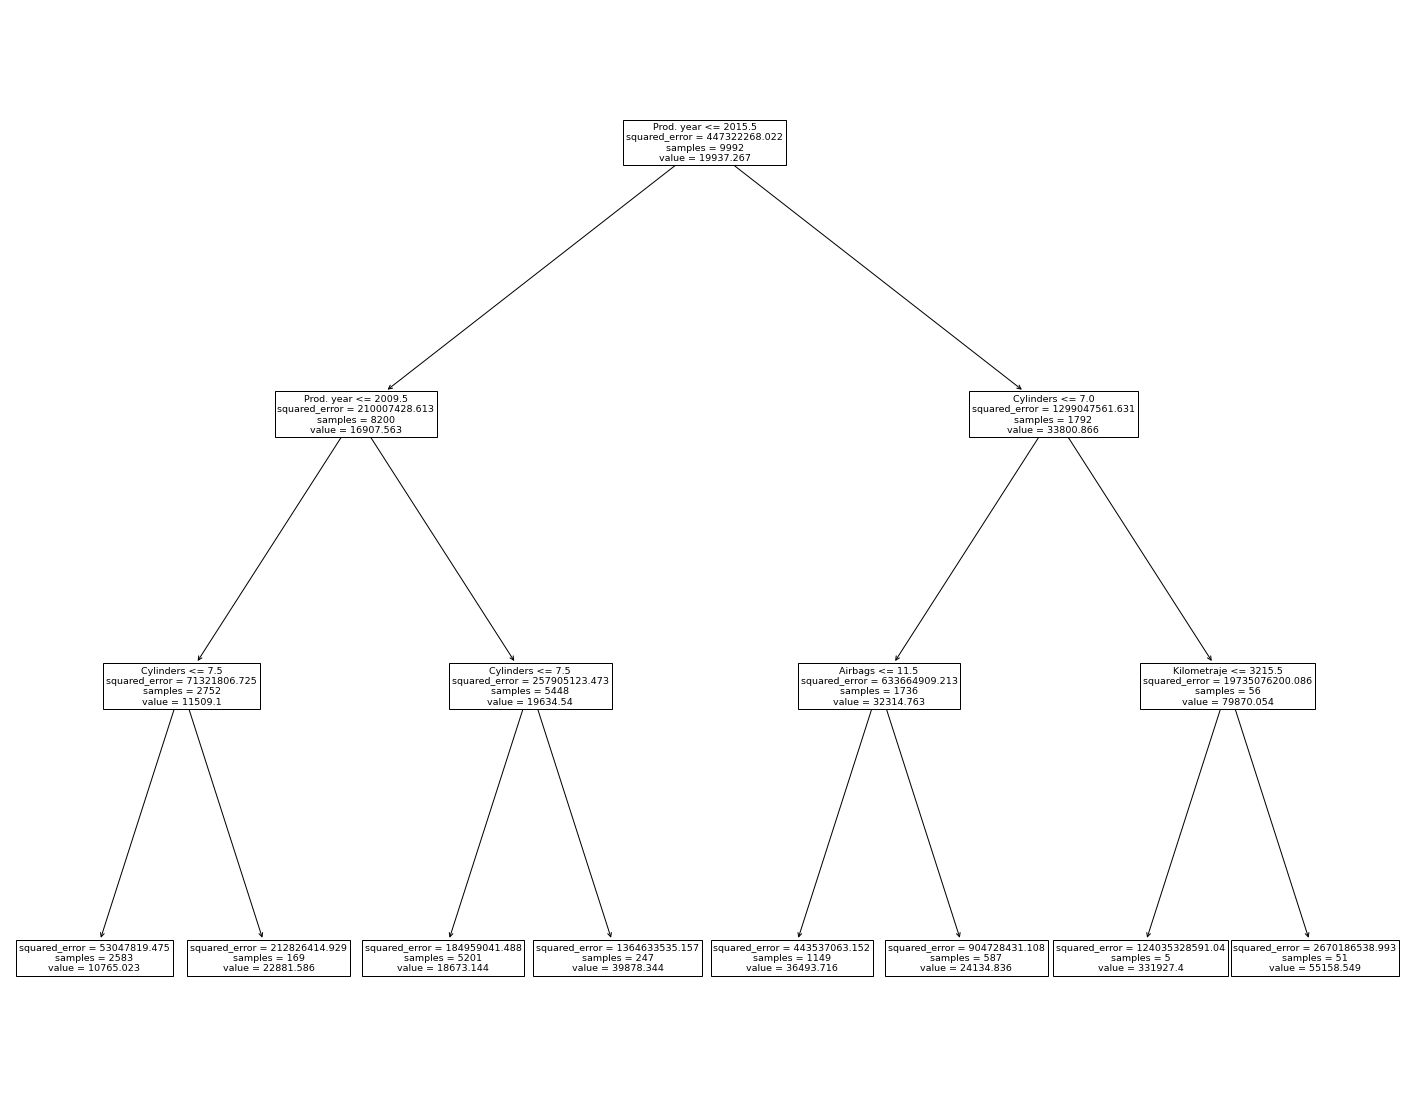

In [42]:
# PINTER AQUI ARBOL DE DECISION GENERADO
import matplotlib.pyplot as plt
from sklearn import tree
fig = plt.figure(figsize=(25,20))
_ = tree.plot_tree(dtr1, feature_names = list(x_train.columns))

Del gráfico vemos que la primera variable usada es el año de producción (lo cuál tiene sentido considerando que era la de mayor correlación), por lo que parece ser que en el primer nivel efectivamente es la variable más importante (la que más ayuda a reducir la entropía). En los niveles 2 y 3 vemos que se usan otras variables como cilindros, airbags, kilometraje y de nuevo el año de producción. Hay algunas que ni siquiera aparecen, puede que sean un poco menos importantes aunque también es cierto que 3 niveles son muy pocos (no se debe tener demasiados niveles pero tampoco un número muy bajo de estos).

### Contrucción de otros modelos y selección del mejor modelo en el conjunto de validación

Ahora, probemos otras opciones de modelos y procedamos a elegir cuál es nuestro modelo en el conjunto de validación.

Podemos construir varios posibles modelos con lo que hemos visto hasta ahora. Uno de ellos es el que acabamos de crear; sin embargo, notar que podemos cambiar el modelo completamente de dos formas principales:

1. Cambiando las variables que usa (modificando la preparación de características).
2. Cambiando los hiperparámetros del modelo.

Al tener varios posibles modelos, vamos a revisar el rendimiento que cada uno de ellos obtendría en el conjunto de validación y elegir el mejor de ellos según sus métricas.

En este caso, cambiaremos los hiperparámetros del modelo para crear otro par más de modelos, y luego pondremos a competir todos para elegir el que sea mejor.

In [43]:
## Crear y entrenar modelo 2, poniendo otra profundidad
dtr2 = DecisionTreeRegressor(random_state = semilla, max_depth = 7)
dtr2.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=7, random_state=42)

In [44]:
## Crear y entrenar modelo 3, poniendo en este caso un número mínimo de 4 observaciones para que consideremos
# que ya llegamos al final de una de las ramas del árbol (y por ende ser un nodo hoja)
dtr3 = DecisionTreeRegressor(random_state = semilla, min_samples_leaf = 4)
dtr3.fit(x_train, y_train)

DecisionTreeRegressor(min_samples_leaf=4, random_state=42)

#### Comparar rendimientos en validación

Ahora sí, calculemos las métricas en validación de nuestros modelos y elijamos el mejor de ellos. Debemos entonces, para cada modelo, generar las predicciones en el conjunto de validación, y comparar estas precicciones con los datos reales de validación para calcular las métricas.


In [45]:
# Predicciones en validacion de los 3 modelos
pred_val1 = dtr1.predict(x_val)
pred_val2 = dtr2.predict(x_val)
pred_val3 = dtr3.predict(x_val)


En nuestro curso, las métricas que usaremos en estos problemas son el MAE, el MSE y el MAPE para compararnos. Estas métricas son de error, por lo que se espera minimizarlas.

In [46]:
# Mirar metricas en validacion de cada uno
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, mean_absolute_error

In [47]:
# Modelo 1
print("Metricas modelo 1: ")
print("MSE: " +  str(mean_squared_error(y_val, pred_val1)))
print("MAE: " + str(mean_absolute_error(y_val, pred_val1)))
print("MAPE: "+ str(mean_absolute_percentage_error(y_val, pred_val1)))

Metricas modelo 1: 
MSE: 230457158.70487177
MAE: 9724.560110684952
MAPE: 1.3126861081628494


In [48]:
# Modelo 2
print("Metricas modelo 2: ")
print("MSE: " +  str(mean_squared_error(y_val, pred_val2)))
print("MAE: " + str(mean_absolute_error(y_val, pred_val2)))
print("MAPE: "+ str(mean_absolute_percentage_error(y_val, pred_val2)))

Metricas modelo 2: 
MSE: 201814276.52500802
MAE: 8477.347091210399
MAPE: 0.9992404289908265


In [49]:
# Modelo 3
print("Metricas modelo 3: ")
print("MSE: " +  str(mean_squared_error(y_val, pred_val3)))
print("MAE: " + str(mean_absolute_error(y_val, pred_val3)))
print("MAPE: "+ str(mean_absolute_percentage_error(y_val, pred_val3)))

Metricas modelo 3: 
MSE: 209937506.66267857
MAE: 8097.529298112653
MAPE: 0.8129290406298239


De esta forma, elegiremos entonces el modelo con mejores métricas (para este caso, buscar el valor menor para estas 3 métricas, pero notar que muchas otras métricas fuera de estas 3 en las que puede que se busque valores mayores como el R2).


El modelo 1 vemos que presenta el peor resultado entre los 3 ya que en las 3 métricas es el peor, por lo que sabemos 100% que no es el mejor.

Entre el modelo 2 y 3, es un poco más difícil decidir, ya que en MSE gana el 2 pero en MAE y MAPE gana el 3. Esto es algo que pasa muy frecuente en la realidad, a veces un solo modelo no va a ganar en todas las métricas, y toca analizar para decidir cuál seleccionar.

En este caso, teniendo en cuenta que el modelo 3 gana en 2 de las 3 métricas, y que el MAE y MAPE suelen ser más fáciles de entender y explicar para los humanos, voy a seleccionar el modelo 3 como mejor modelo.

### Modelo seleccionado

Así, nuestro modelo seleccionado de esta fase es el modelo 3.
Lo voy a seleccionar como mejor modelo en el notebook.

In [50]:
# Copiar el modelo elegido usando clone
# notar que esto copia la arquitectura del modelo, pero no está entrenado 
# (para usarlo toca reentrenarlo, cómo lo veremos a continuación)

from sklearn.base import clone
modelo_final = clone(dtr3)

#### Ejercicio
Cree un cuarto y quinto modelo, diferentes a los aquí creados, variando los hiperparámetros. Compárelos con los otros 3 y determine si alguno de estos nuevos modelos debería ser el nuevo modelo final elegido.

##### NOTA: No sobreescriba el modelo final, solo haga el análisis correspondiente sin sobreescribirlo.


# Bagging y boosting
# otros modelos de machine learning

### Paréntesis antes de seguir: métricas en train
Como dato curioso, miren las métricas del árbol de decisión elegido en el conjunto de train.

In [51]:
# Metricas en train
pred_train3 = dtr3.predict(x_train)
print("Metricas modelo 3: ")
print("MSE: " +  str(mean_squared_error(y_train, pred_train3)))
print("MAE: " + str(mean_absolute_error(y_train, pred_train3)))
print("MAPE: "+ str(mean_absolute_percentage_error(y_train, pred_train3)))

Metricas modelo 3: 
MSE: 161645193.6294652
MAE: 5528.693539778396
MAPE: 0.4697032316397041


Claramente estas métricas dan mucho mejores que las de validación, pero esto indica que nuestro árbol de decisión singular está cometiendo overfitting y está memorizando muchas soluciones en vez de aprender bien esos patrones (por ejemplo, memorizar el kilometraje exacto de un carro para dar una predicción no es tan buena idea).

Usemos entonces técnicas de boosting y bagging para intentar mitigar ese overfitting y mejorar el rendimiento de nuestro modelo.

### Bagging: random forest

Usemos entonces primero el método de random forest para ver qué tanto logramos mejorar nuestrar predicciones usando esta clase de modelos.

Recordemos que en estos modelos, se construye un bosque de árboles independientes que trabajan en paralelo, y luego en consenso todos ellos generan la predicción final.

Los dos hiperparámetros más importantes de este modelo suelen ser el número de árboles en el bosque (debe ser suficientemente grande para lograr reducir la varianza, pero no demasiado grande para que no tarde demasiado tiempo corriendo) y la profundidad de los árboles (usualmente se manejan árboles con profundidad alta para minimizar el bias en cada árbol).

Creemos y entrenemos entonces tres modelos diferentes de random forest (https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html) y veamos sus métricas:

In [52]:
from sklearn.ensemble import RandomForestRegressor

In [53]:
# Inicializar los 3 modelos
rf1 = RandomForestRegressor(random_state = semilla) # Parametros por defecto
rf2 = RandomForestRegressor(random_state = semilla, n_estimators = 200) # 200 árboles en el bosque
rf3 = RandomForestRegressor(random_state = semilla, max_depth = 8) # Cambiar profundidad maxima

Entrenemos ahora los modelos (notar que se demoran un poco corriendo algunos de ellos):

In [54]:
# Entrenar los 3 modelos
rf1.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

In [55]:
rf2.fit(x_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [56]:
rf3.fit(x_train, y_train)

RandomForestRegressor(max_depth=8, random_state=42)

In [57]:
# Predicciones en validacion de los 3 modelos rf
pred_val_rf1 = rf1.predict(x_val)
pred_val_rf2 = rf2.predict(x_val)
pred_val_rf3 = rf3.predict(x_val)


In [58]:
# Random forest 1
print("Metricas random forest 1: ")
print("MSE: " +  str(mean_squared_error(y_val, pred_val_rf1)))
print("MAE: " + str(mean_absolute_error(y_val, pred_val_rf1)))
print("MAPE: "+ str(mean_absolute_percentage_error(y_val, pred_val_rf1)))

Metricas random forest 1: 
MSE: 172710364.75806382
MAE: 7281.509503108808
MAPE: 0.7271611640258571


In [59]:
# Random forest 2
print("Metricas random forest 2: ")
print("MSE: " +  str(mean_squared_error(y_val, pred_val_rf2)))
print("MAE: " + str(mean_absolute_error(y_val, pred_val_rf2)))
print("MAPE: "+ str(mean_absolute_percentage_error(y_val, pred_val_rf2)))

Metricas random forest 2: 
MSE: 170562513.64498296
MAE: 7255.450315228055
MAPE: 0.7284439442939554


In [60]:
# Random forest 3
print("Metricas random forest 3: ")
print("MSE: " +  str(mean_squared_error(y_val, pred_val_rf3)))
print("MAE: " + str(mean_absolute_error(y_val, pred_val_rf3)))
print("MAPE: "+ str(mean_absolute_percentage_error(y_val, pred_val_rf3)))

Metricas random forest 3: 
MSE: 165157996.2429209
MAE: 7749.888653842029
MAPE: 0.9444857306132234


Solo cambiando el tipo de modelo de decision tree a random forest ya logramos notar mejoras muy claras en varias de las métricas (los MAE ya los logramos bajar de 8 mil a 7 mil 200), lo que representa una gran ganancia. 

Sería claramente ideal probar con muchas otras combinaciones de hiperparámetros para mejorar más el modelo.

### Boosting: gradient boosting

Usemos entonces ahora el método de gradient boosting para ver qué tanto logramos mejorar nuestras predicciones usando esta clase de modelos.

Recordemos que en estos modelos, se construye un conjunto de árboles dependientes sucesivos que trabajan en serie, y la predicción final se obtiene luego de pasar por toda la serie de árboles.

Los dos hiperparámetros más importantes de este modelo suelen ser el número de árboles en el modelo (debe ser suficientemente grande para lograr reducir el bias, pero no demasiado grande para que no tarde demasiado tiempo corriendo) y la profundidad de los árboles (usualmente se manejan árboles con profundidad baja para minimizar la varianza).

Creemos y entrenemos entonces tres modelos diferentes de gradient boosting (https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html) y veamos sus métricas:

In [61]:
from sklearn.ensemble import GradientBoostingRegressor

In [62]:
# Inicializar los 3 modelos
gb1 = GradientBoostingRegressor(random_state = semilla) # Parametros por defecto
gb2 = GradientBoostingRegressor(random_state = semilla, n_estimators = 200) # 200 árboles en el modelo
gb3 = GradientBoostingRegressor(random_state = semilla, max_depth = 8) # Cambiar profundidad maxima

Entrenmos ahora los modelos (notar que se demoran un poco corriendo algunos de ellos):

In [63]:
# Entrenar los 3 modelos
gb1.fit(x_train, y_train)

GradientBoostingRegressor(random_state=42)

In [64]:
gb2.fit(x_train, y_train)

GradientBoostingRegressor(n_estimators=200, random_state=42)

In [65]:
gb3.fit(x_train, y_train)

GradientBoostingRegressor(max_depth=8, random_state=42)

In [66]:
# Predicciones en validacion de los 3 modelos gb
pred_val_gb1 = gb1.predict(x_val)
pred_val_gb2 = gb2.predict(x_val)
pred_val_gb3 = gb3.predict(x_val)


In [67]:
# Gradient boosting 1
print("Metricas gradient boosting 1: ")
print("MSE: " +  str(mean_squared_error(y_val, pred_val_gb1)))
print("MAE: " + str(mean_absolute_error(y_val, pred_val_gb1)))
print("MAPE: "+ str(mean_absolute_percentage_error(y_val, pred_val_gb1)))

Metricas gradient boosting 1: 
MSE: 183228663.3385087
MAE: 8252.21866768274
MAPE: 1.0081881390591854


In [68]:
# Gradient boosting 2
print("Metricas gradient boosting 2: ")
print("MSE: " +  str(mean_squared_error(y_val, pred_val_gb2)))
print("MAE: " + str(mean_absolute_error(y_val, pred_val_gb2)))
print("MAPE: "+ str(mean_absolute_percentage_error(y_val, pred_val_gb2)))

Metricas gradient boosting 2: 
MSE: 180571506.54229334
MAE: 8088.08646631209
MAPE: 0.9633496740144645


In [69]:
# Gradient boosting 3
print("Metricas gradient boosting 3: ")
print("MSE: " +  str(mean_squared_error(y_val, pred_val_gb3)))
print("MAE: " + str(mean_absolute_error(y_val, pred_val_gb3)))
print("MAPE: "+ str(mean_absolute_percentage_error(y_val, pred_val_gb3)))

Metricas gradient boosting 3: 
MSE: 166375973.86641937
MAE: 7312.842209513623
MAPE: 0.8079279083940377


En este caso el mejor modelo de los probados de gradient boosting resulta ser el tercero, obteniendo un MAE de 7 mil 300 (rendimiento similar a los mejores modelos de random forest).

Sería claramente ideal probar aquí también con muchas otras combinaciones de hiperparámetros para mejorar más el modelo.

### Y muchos otros modelos...

Recordar entonces que toda esta misma estructura usada se puede usar con muchos otros tipos de modelo que apliquen en problemas supervisados de regresión.

En scikit-learn existen muchos otros tipos de modelos que se pueden importar y usar de forma análoga a los que hemos usado.

Por ejemplo, la regresión lineal la podríamos usar así:

In [70]:
from sklearn.linear_model import LinearRegression

In [71]:
# Inicializar la regresion lineal
lr = LinearRegression() # Parametros por defecto

In [72]:
# Entrenar
lr.fit(x_train, y_train)

LinearRegression()

In [73]:
# Predicciones en validacion
pred_val_lr = lr.predict(x_val)


In [74]:
# Gradient boosting 1
print("Metricas regresión lineal 1: ")
print("MSE: " +  str(mean_squared_error(y_val, pred_val_lr)))
print("MAE: " + str(mean_absolute_error(y_val, pred_val_lr)))
print("MAPE: "+ str(mean_absolute_percentage_error(y_val, pred_val_lr)))

Metricas regresión lineal 1: 
MSE: 248834635.08052543
MAE: 10213.186936262056
MAPE: 1.4416570459185878


Cómo se nota aquí, la regresión lineal es bastante mala en este ejercicio, esto indica que las relaciones entre nuestras variables explicativas y la variable de salida claramente no son de tipo lineal (algo que se evidenciaba en la correlación ya que había muy pocas correlaciones relativamente importantes).

### NOTA:
Tenga en cuenta que, a pesar de que en esta parte nueva muy probablemente se hallaron modelos mucho mejores, las secciones a continuación tienen el mismo análisis del modelo elegido en el notebook pasado (donde se introdujo este módulo).

Si se cambiara aquí el modelo elegido, el ANÁLISIS de las siguientes dos etapas cambiará por completo; sin embargo, el código en si debería seguir funcionando correctamente, lo cual es bastante bueno (sea cual sea el modelo, los códigos y pasos a seguir de las dos etapas siguen siendo muy similares, lo que cambian son los resultados y su análisis)

### Ejercicios sugeridos:

Cree los siguientes modelos supervisados de regresión y compare su rendimiento en validación con los otros modelos creados anteriormente:

1. k-NN con 6 vecinos.

2. Random forest donde en cada división se revisen solamente de forma aleatoria la mitad de las características (features) para elegir la variable a usar en la división.

3. Red neuronal básica (multi-layer perceptron) con una sola capa con 60 neuronas.

4. Red neuronal básica (multi-layer perceptron) con dos capas, cada una con 25 neuronas.

5. Extreme gradient boosting (xgboost). Note que este modelo no usa la librería sklearn sino otra que se llama xgboost.

6. (opcional) Intenten crear un random forest de 10000 árboles. ¿Qué ocurre?

### NOTA:

Recuerden que todos los bloques posteriores a este punto usan el "modelo elegido", el cual teníamos desde el notebook pasado como el modelo 3 de decision tree. Si se cambia el modelo elegido, todo este código debería seguir funcionando, pero todos los análisis cambiarían.

## 5. Evaluación

Ahora que ya tenemos nuestro modelo final, evaluemos cómo le fue a este modelo.

Esto suele incluir diversos ítems:

- Calcular y analizar todas las métricas en el conjunto de prueba (recordar que "test" es prueba en inglés).

- Presentar algunas visualizaciones (ejemplo: error estimado por modelo,  o ver las variables más importantes del modelo final escogido).

- Decidir si se resolvieron los objetivos de negocio.

### Primero, calcular y analizar las métricas del modelo elegido en Prueba

Empecemos primero entonces por entrenar nuestro modelo final escogido.

El modelo ahora debe entrenarse con todo el conjunto de entrenamiento y validación, ya que vamos a mirar su rendimiento en el conjunto de test y podemos usar el resto de datos para entrenarlo.

In [75]:
# Entrenar el modelo elegido con los conjuntos de entrenamiento y validación
x_train_val = pd.concat([x_train, x_val])
y_train_val = pd.concat([y_train, y_val])
modelo_final.fit(x_train_val, y_train_val )

DecisionTreeRegressor(min_samples_leaf=4, random_state=42)

In [76]:
# Generar las predicciones para el conjunto de test
pred_test = modelo_final.predict(x_test)

Calculemos entonces las métricas para el conjunto de test. Si todo sale bien, deberíamos ver valores similar a los que vimos en el paso anterior en el conjunto de validación. 

Si los valores que vemos son muy difernetes, esto es una señal de alarma de que probablemente no hicimos bien la división del conjunto o de que nuestro modelo se enfocó demasiado en el conjunto de validación y no es bueno generalizando, por lo que se sugiere regresar y corregirlo.

In [77]:
### Metricas en test
print("Metricas modelo elegido en test: ")
print("MSE: " +  str(mean_squared_error(y_test, pred_test)))
print("MAE: " + str(mean_absolute_error(y_test, pred_test)))
print("MAPE: "+ str(mean_absolute_percentage_error(y_test, pred_test)))

Metricas modelo elegido en test: 
MSE: 227351072.92897752
MAE: 8080.940605065788
MAPE: 0.6995604051194894


Vemos que las métricas son relativamente parecidas a las de validación, lo cual indica que el modelo está generalizando correctamente con nuevos datos que no ha visto.

Estas métricas de test (prueba) son las que sí representan realmente cómo se comportara nuestro modelo a futuro, y son muy importantes para el Negocio puesto que nos ayudan a saber qué esperamos que pase en el futuro (ejemplo: el MAE nos dirá en promedio cuánto nos desfasamos al ponerle precio a nuestros vehículos con el modelo, lo cuál es muy importante saberlo para el equipo de negocio).

Con estos valores debemos determinar si se cumplieron los objetivos de negocio que definimos en conjunto con el equipo de negocio. Aquí es muy importante que el equipo de negocio quede satisfecho con el modelo.

Si por ejemplo el MAE visto aquí estuviera diciendo que en promedio nos equivocamos en 50 mil dólares al ponerle precio a los autos, es muy probable que el equipo de negocio no quede contento con ese posible error. En ese caso, no se cumpliría el objetivo y tocaría volver al inicio del CRISP-DM para ver posibles formas de solucionar esto.

### Gráficas para entender mejor el rendimiento del modelo

Ahora, aquí se pueden ver también algunas gráficas que le ayuden al equipo de negocio a entender mejor el rendimiento del modelo. Algunas de estas pueden estar relacionadas con las preguntas de negocio (ejemplo: puede que una pregunta de negocio fuera "¿qué tan bien podemos predecir el precio para los autos de marca Toyota?", aquí podríamos analizar eso).

Para hacer algunos de estos análisis, primero calculemos todos los errores absolutos en el conjunto de prueba.

In [78]:
# Primero, calcular los errores absolutos
err_abs = abs(pred_test - y_test)
err_abs

5483     3267.000000
8821     3628.714286
1215     2146.250000
3950     3611.250000
13558    6713.800000
            ...     
13206    5027.666667
8887     2391.500000
111        78.000000
12583    1058.250000
16479    3554.333333
Name: Price, Length: 3331, dtype: float64

In [79]:
# Mirar que la media de esto es el mismo MAE
err_abs.mean()

8080.940605065794

Luego, consolidemos un conjunto de datos de test con todas las variables originales y los errores absolutos.

In [80]:
err_abs

5483     3267.000000
8821     3628.714286
1215     2146.250000
3950     3611.250000
13558    6713.800000
            ...     
13206    5027.666667
8887     2391.500000
111        78.000000
12583    1058.250000
16479    3554.333333
Name: Price, Length: 3331, dtype: float64

In [81]:
# Dejar solo las filas que correspondían a indices que están en test
data_filtered_test = data_filtered[data_filtered.index.isin(x_test.index)]

# Pegarle los errores absolutos de predicción
data_filtered_test["Error absoluto"] = err_abs
data_filtered_test.head()

,ID,Price,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags,Error absoluto
0,45654403,13328,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12,44.928571
15,45801686,18826,HYUNDAI,Elantra,2012,Sedan,Yes,Petrol,1.6,112645 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4,2073.600000
19,45813492,4704,OPEL,Vectra,1995,Sedan,No,Petrol,1.8,0 km,4.0,Automatic,Front,04-May,Left wheel,Green,4,819.000000
29,45642526,7527,HONDA,FIT,2010,Hatchback,No,Hybrid,1.3,158000 km,4.0,Automatic,Front,04-May,Right-hand drive,Black,4,7058.500000
31,45815051,24462,TOYOTA,Camry,2013,Sedan,Yes,Petrol,2.4,203200 km,4.0,Automatic,Front,04-May,Left wheel,Blue,4,1245.000000


Con el conjunto anterior, ya podemos empezar a responder preguntas de negocio relacionadas con las predicciones que se esperan de nuestro modelo.

Por ejemplo, miremos cómo varía el error mediano del precio de un vehículo según el año de producción:

<AxesSubplot:xlabel='Prod. year'>

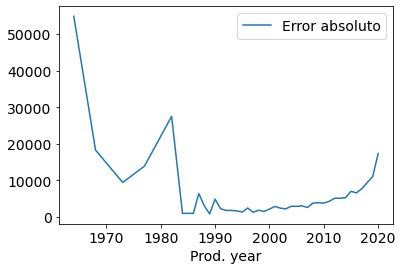

In [82]:

data_marca_means = data_filtered_test.groupby('Prod. year', as_index=False)['Error absoluto'].median()
data_marca_top_means = data_marca_means.sort_values(by="Prod. year")
data_marca_top_means.plot.line(x = "Prod. year")


De la gráfica vemos que con autos de modelos de entre 1990 y 2010, nuestro modelo suele tener un rendimiento correcto y no fallar por mucho (como 1 o 2 mil dólares máximo, pero teniendo en cuenta que hay autos de todo tipo de gama, esto no es tanto). 

Sin embargo, es de interés notar que parece que con los modelos de años más recientes este error ha ido subiendo y subiendo, lo cuál sería preocupante ya que para el equipo de negocio probablemente los carros más relevantes son justamente los de modelos más recientes, ya que en el futuro seguirán llegan cada vez modelos más nuevos.

Ahora, grafiquemos el top 10 de marcas con menor error promedio de nuestro modelo.

<AxesSubplot:xlabel='Manufacturer'>

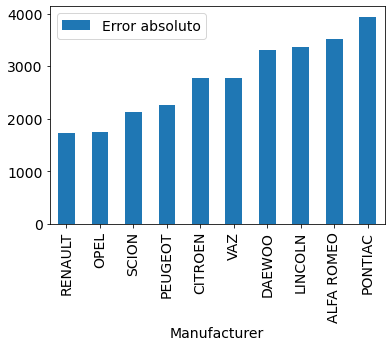

In [83]:
data_marca_means = data_filtered_test.groupby('Manufacturer', as_index=False)['Error absoluto'].mean()
data_marca_top_means = data_marca_means.sort_values(by="Error absoluto")[:10]
data_marca_top_means.plot.bar(x = "Manufacturer", y = "Error absoluto")

La gráfica anterior muestra que en marcas de carro como Renault y OPEL, el modelo lograra predecir muy bien los precios, fallando en promedio solamente en más o menos 1600 dólares para estos.

Adicionalmente, los árboles permiten ver cuáles fueron las varibles más usadas por el árbol, lo que da una noción de cuáles son las variables más importantes para modelar el precio de los vehículos.

<AxesSubplot:>

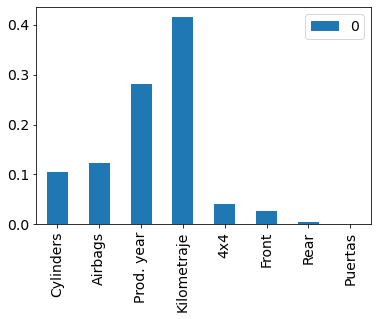

In [84]:
# Graficar feature importances para ver las variables más usadas por nuestro árbol
# Tener en cuenta que que en el modulo 4 profundizaremos mas en esteb tema
importancias_variables =  pd.DataFrame(modelo_final.feature_importances_, index = list(x_train_val.columns))
importancias_variables.plot.bar()

En la gráfica vemos que en el árbol las variables que más se usaron fueron Prod. Year y Kilometraje, lo que nos da una noción de que fueron las más importantes para este modelo (lo cual se alinea con lo que conocemos, y aquí es curioso ver que kilometraje sí se usa mucho en el modelo). Cilindros y airbags parecen estar en un segundo grado, mientras que puertas parece ser la menos usada. Recuerden que en el módulo 4 exploraremos más el tema de importancia de variables.

##### NOTA:
Sin embargo, tenga en cuenta que aquí solo estamos midiendo cuáles variables se usaron más en nuestro árbol, y no necesariamente cuáles eran más importantes para nuestro estudio. Las variables continuas se suelen usar muchas más veces puesto que tienen más posibles divisiones que las categóricas, lo que sesga las "importancias" que aquí vemos.



#### Ejercicio:
Cree una gráfica que permita responder la pregunta de negocio ""¿qué tan bien podemos predecir el precio para los autos de marca Toyota?" a través de una visualización.

Pista: grafique la distribución de errores para dicho escenario y analíce la gráfica.

##################################################################################
##################################################################################
##################################################################################
##################################################################################
##################################################################################

# PARTE NUEVA

Esta es la única parte del notebook diferente con respecto al notebook anterior visto en clase (se agregan aquí unos análisis). Sin embargo, no modificaré en esta sección nada del modelo seleccionado ni ninguna otra variable para no alterar el resto de los análisis hechos previamente en las etapas 5 y 6 de CRISP-DM.

# Métricas y sus intervalos de confianza:


Retomemos entonces el modelo seleccionado (de la variable modelo_final) y sus errores en el conjunto de prueba. Recordemos que estamos siendo consistentes con la primera versión del notebook, en la cual el "modelo_final" escogido fue el dtr3 (decision tree 3). Las muestras de residuos del error son las que usaremos para calcular los intervalos de confianza:



In [100]:
### Residuos en el conjunto de prueba
res = (pred_test - y_test).values
res

array([-3267.        , -3628.71428571, -2146.25      , ...,
          78.        ,  1058.25      , -3554.33333333])

En el caso anterior, los negativos indican que nuestra predicción de precio fue menor que el precio real, mientras que los positivos indican lo contrario.

Ahora, los residuos absolutos:

In [101]:
### Residuos absolutos en el conjunto de prueba
res_abs = np.abs(res)
res_abs

array([3267.        , 3628.71428571, 2146.25      , ...,   78.        ,
       1058.25      , 3554.33333333])

In [102]:
res_abs.mean()

8080.940605065788

Obteniendo directamente el MAE y MSE en el conjunto de prueba, como ya habíamos visto, se obtiene lo siguiente:



In [103]:
### Metricas en test
print("Metricas modelo elegido en test: ")
print("MSE: " +  str(mean_squared_error(y_test, pred_test)))
print("MAE: " + str(mean_absolute_error(y_test, pred_test)))
print("MAPE: "+ str(mean_absolute_percentage_error(y_test, pred_test)))

Metricas modelo elegido en test: 
MSE: 227351072.92897752
MAE: 8080.940605065788
MAPE: 0.6995604051194894


Sin embargo, aquí solo tenemos una estimación puntual de este valor, pero queremos explorar más a fondo su comportamiento.

Miremos primero la evolución de los residuales y de sus valores absolutos con boxplots e histogramas.

### Histogramas

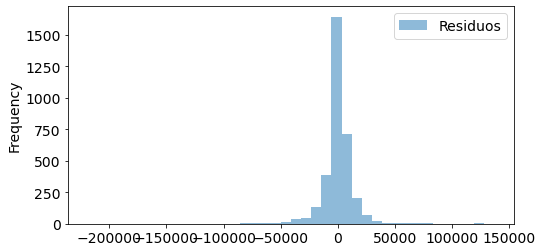

In [104]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

DF = pd.DataFrame({'Residuos': res})
ax = DF.plot.hist(bins=40, alpha=0.5, figsize=(8,4))

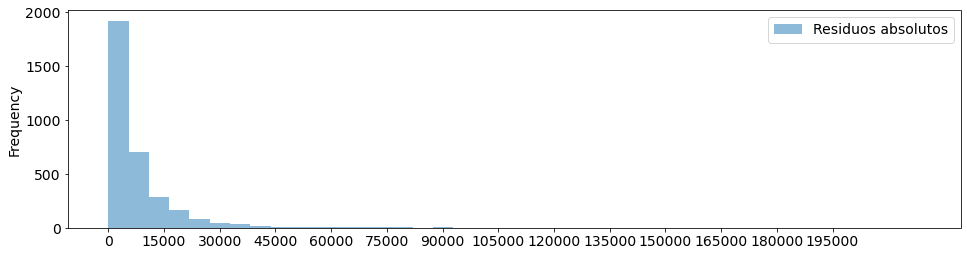

In [105]:
DF = pd.DataFrame({'Residuos absolutos': res_abs})
ax = DF.plot.hist(bins=40, alpha=0.5, figsize=(16,4), xticks=range(0,200000,15000))

De las gráficas anteriores vemos que el error que puede cometer el modelo en este escenario suele variar casi siempre entre -15000 y 15000, y hay una concentración importante de estos entre -5000 y 5000. 

Aquí se nota algo muy curioso: a pesar que el MAE del modelo es 8000 como ya vimos, en los histogramas se aprecia que en realidad una gran cantidad de los errores absolutos son menores a 5000 (parece ser más del 50%). Confirmemos con la mediana:


In [106]:
np.median(res_abs)

4234.25

Efectivamente, a pesar de que el error medio absoluto es 8080, el error mediano absoluto es solo de 4234, lo cual marca una gran diferencia. Esto demuestra que hay "outliers" que están afectando mucho nuestra media. (en el 50% de los casos, nuestro modelo se equivoca máximo en 4234 dólares). 

Los carros de alta gama, al tener costos mucho más altos que los demás, probablemente están generando este efecto: si calcularamos el MAE solamente para los autos "más comunes" comercialmente (es decir, descartar todos los autos lujosos y dejar solo los más comunes en le la población general), probablemente nos daríamos cuenta de que nuestro modelos se equivoca en promedio en alrededor de 4000 dólares al asignar precios, lo cuál resulta mucho más preciso e interesante para un posible equipo de negocio que quiera usar este modelo en autos que excluyan a los de gama alta.

#### Boxplot de residuales 

Analicemos ahora los boxplots de residuales.


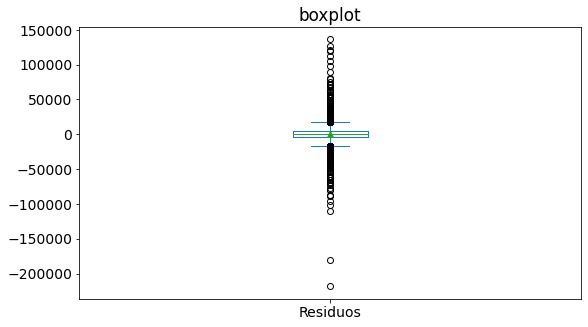

In [107]:
DF = pd.DataFrame({'Residuos': res})
ax = DF.plot(kind='box', title='boxplot', showmeans=True, figsize=(9,5))

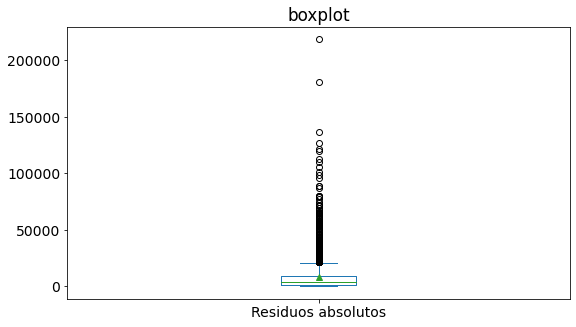

In [108]:
DF = pd.DataFrame({'Residuos absolutos': res_abs})
ax = DF.plot(kind='box', title='boxplot', showmeans=True, figsize=(9,5))

Los boxplots corroboran lo visto arriba: en los residuos originales, se ve un centro en 0 y una distribución muy contenida entre -5000 y 5000. Y además, se observan los valores muy extremos de errores absolutos de más de 100 mil que son los que parecen estar sesgando el MAE.

### Test de normalidad

Apliquemos tests de normalidad a los residuos en cada escenario para ver si se ajustan o no a esta distribución.

La hipótesis nula en esta prueba es que los datos son normales, y la alternativa que no lo son.

In [109]:
### Residuos
from scipy import stats

k2, p = stats.normaltest(res)

print("p = {:g}".format(p))

p = 2.958e-295


In [110]:
### Residuos absolutos

k2, p = stats.normaltest(res_abs)

print("p = {:g}".format(p))

p = 0


Como se puede ver en estos tests de normalidad, hay evidencia muy significativa para saber que los residuos no siguen una distribución normal, por lo que debemos tener esto en cuenta para cualquier estimación futura que haríamos con ellos.


### Intervalo de confianza de la media de los residuos

Basado en :https://towardsdatascience.com/how-to-calculate-confidence-intervals-in-python-a8625a48e62b


###### Procedemos a estimar la media de los residuos, y un intervalo de confianza para esta.

Tengamos en cuenta que lo que estamos buscando estimar es la media, y por el teorema del límite central, si se cumplen ciertos supuestos, esta debería distribuirse normal.

https://www.google.com/search?client=firefox-b-d&q=teorema+del+limite+central+media+normal

Uno de los supuestos es el supuesto de independencia de los residuos, el cual si quisieramos podríamos chequear con el test de Ljung-box. 

https://www.analyticsvidhya.com/blog/2019/05/statistics-101-introduction-central-limit-theorem/

Por ahora, usemos los intervalos de confianza clásicos de la media de una población para estimar el MAE y el MSE de los residuos (sin validar si se cumplen o no los supuestos).

Así, procedamos a hallar el intervalo de confianza clásico para el MAE y el MSE (para las medias de una población).

En este caso, usemos la distribución T-Student (la cual se usa en casos donde la muestra no es tan grande). La fórmula sería esta https://slideplayer.com/slide/4462607/14/images/8/Confidence+Interval+Estimate+Use+Student%E2%80%99s+t+Distribution+%3A.jpg, y la calculamos desde código así:

In [111]:
# MAE
from scipy.stats import t
x = res_abs.copy() # Aqui se pone la muestra a usar
confidence = 0.95 # Nivel de confianza

# Se proceden a calcular los valores el intervalo de confianza
# Notar que aqui estamos usando la formula para intervalos de confianza t-student 
m = x.mean() 
s = x.std() 
dof = len(x)-1 

t_crit = np.abs(t.ppf((1-confidence)/2,dof))
#t_crit=1.96

out= (m-s*t_crit/np.sqrt(len(x)), m+s*t_crit/np.sqrt(len(x))) 

print(np.mean(np.abs(res_abs)))
print(out)

8080.940605065788
(7648.48406770323, 8513.397142428346)


El de arriba es un intervalo de confianza del 95% para el MAE: entre 7648 y 8513. Así, podríamos concluir con un 95% de confianza, que en cualquier otra muestra (de tamaño significativo), si usáramos el modelo para realizar sus predicciones, el MAE que obtendríamos variaría entre 7648 y 8513. Esto ya se vuelve de mucho más valor para el cliente final: con este intervalo pueden saber cómo se comportarían sus métricas en diversos escenarios.

Podriamos apretarlo este intervalo más, por ejemplo con un nivel de confianza de 90%.

In [112]:
confidence = 0.90
t_crit = np.abs(t.ppf((1-confidence)/2,dof))
out= (m-s*t_crit/np.sqrt(len(x)), m+s*t_crit/np.sqrt(len(x))) 

print(out)

(7718.042596030461, 8443.838614101116)


#### Ejercicio:

Teniendo en cuenta que aquí n>30, se puede usar los intervalos de confianza clásicos con base en la distribución normal y deben dar muy similares a los de arriba.

1. Calcule el intervalo de confianza clásico del 95% (con la aproximación a la distribución normal) para el MAE y compárelo con el de arriba.

2. Calcule un intervalo de confianza del 99% para el MSE.

### Intervalo de confianza no paramétrico

Ahora bien, como mencionamos anteriormente, para usar estos intervalos de confianza era necesario hacer varios supuestos que no siempre se cumplirán, debido a que son intervalos de confianza paramétricos.

Como alternativa, podemos usar intervalos de confianza no parámetricos.


#### Intervalos de confianza Bootstrap: percentile confidence intervals

Imagen: https://stats.stackexchange.com/questions/246726/size-of-bootstrap-samples![image.png](attachment:image.png)

Pasos: https://www.sciencedirect.com/topics/mathematics/bootstrap-confidence-interval

Este consiste en generar n muestras distintas con reemplazo de los datos, y para cada una de estas muestras estimar el estadístico deseado. Con esta muestra de n estadísticos, se puede obtener una estimación (media) de su valor e incluso los percentiles de esta distribución pueden formar intervalos de confianza (por ejemplo, los percentiles 2.5 y 97.5 para un intervalo de confianza del 95%).

Por ejemplo, el siguiente código muestra como hallar el intervalo de confianza para la media de una distribución normal, usando bootstrap:

In [113]:
#Generar de forma aleatoria una muestra de una normal con media 300 y desviacion estandar 15
import numpy as np
n=50 
x = np.random.normal(loc= 300.0, scale=15, size=n)
x

array([324.36518045, 290.8236538 , 292.07742372, 283.90547067,
       312.98111444, 265.47691955, 326.17217646, 288.58189649,
       304.78558644, 296.25944437, 321.93161906, 269.09788936,
       295.16374194, 294.23918468, 317.00654164, 283.50163099,
       297.41357689, 286.83212373, 300.6332062 , 308.74222821,
       283.49071234, 317.17085565, 313.52386081, 307.53741508,
       313.51283924, 289.74408211, 298.15664662, 285.96345849,
       295.98167881, 307.955332  , 289.62508872, 294.0486971 ,
       289.6924095 , 287.32191538, 289.93130804, 299.81003102,
       283.24034477, 303.51623547, 324.89703266, 311.13066241,
       297.12246671, 286.68556554, 288.79262559, 325.38681902,
       300.76211632, 290.4450653 , 302.86373227, 331.50382705,
       301.80238429, 309.25804665])

Ahora, Genero un número grande de muestras bootstrap con repetición, y a cada una, le calculo el estadístico (en este caso
calcular la media a cada muestra).

In [114]:
sample_mean = []
n=len(x)
for i in range(10000):
  y = np.random.choice(x.tolist(), n) ### esta es cada una de las muestras bootstrap, muestra aleatoria con repetición
  avg = np.mean(y) # la media de cada muestra
  sample_mean.append(avg) # ir guardando las medias


In [115]:
### Aqui habria entonces 10000 medias, una para cada muestra
len(sample_mean)

10000

In [116]:
sample_mean[:6]

[297.34936910924125,
 299.06961052791183,
 299.6835842256024,
 302.4021459432762,
 300.4233229641263,
 298.24569275431423]

Teniendo las medias de cada muestra, solo tengo entonces que usar los percentiles apropiados para tener mi intervalo de confianza.

Los percentiles para un intervalo de 95% seria tomar "el 95% de la mitad", es decir, del 2.5 al 97.5.

Recordar la definición de percentil: . Por ejemplo el percentil 5 es aquel valor para el cual el 95% de los datos lo superan en valor. El percentil 50 sería la mediana.

Así, el intervalo de confianza del 95% para este escenario sería entonces:


In [117]:

print('Media real poblacional: 300')
print('Media muestra: ' +str(np.mean(x)))

print('Intervalo de confianza inferior: '+str(np.percentile(sample_mean, 2.5)))
print('Intervalo de confianza superior: '+str(np.percentile(sample_mean, 97.5)))

Media real poblacional: 300
Media muestra: 299.61727727988523
Intervalo de confianza inferior: 295.548625094499
Intervalo de confianza superior: 303.77172612030756


También podríamos por ejemplo graficar todas las medias de cada muestra de bootstrap (las 10mil). MIrar como se ve el intervalo de confianza del 95%:

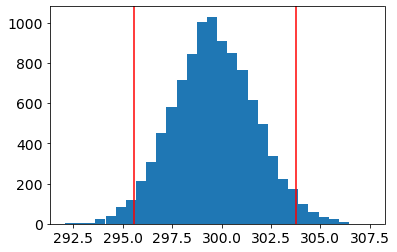

In [118]:
plt.hist(sample_mean, bins=30)
plt.axvline(x = np.percentile(sample_mean, 2.5), color = 'r', label = 'axvline - full height') ## Intervalo inferior
plt.axvline(x = np.percentile(sample_mean, 97.5), color = 'r', label = 'axvline - full height') ## Intervalo superior


(Notar que cada vez que se ejecute el ejercicio, los resultados cambiarán al ser una muestra aleatoria. Sin embargo, se esperaría que casi siempre, el intervalo de confianza generado logre incluir la media real de la población que sabemos que es de 300 ya que esa fue la que usamos al generar la muestra).

#### Ejercicio:

1. Usando bootstrap genere los intervalos de confianza del 90% y del 95% para el MAE y MSE de los residuos del modelo. Compare los intervalos del 95% obtenidos con los intervalos obtenidos por el método anterior (basado en la distribución normal).

2. Adicionalmente, genere un intervalo de confianza del 95% para el percentil 1 de los residuos originales usando bootstrap. Este tipo de cálculos son muy utilizados en finanzas (value at risk), ya que se busca saber, en el 95% de los casos, cuál será el "peor error negativo" (pérdida) en el que incurrirá el modelo. 

3. Tener en cuenta que en nuestro notebook, un error negativo significa que predijo un precio inferior al precio real del carro. Analice, ¿qué tan grave será ese tipo de error? ¿Serán peores los errores negativos o los errores positivos en nuestro escenario? (pista: depende de si estamos pensando cómo compradores o como vendedores).

# Comparación estadística de modelos (poblaciones)

### A/B testing

En el campo de la experimentación estadística, es muy común utilizar A/B testing para probar el efecto de algo, comparando un grupo de control contra un grupo con tratamiento.

En este caso, podría usarse para comparar pares de modelos, donde los residuos absolutos (asociados con el MAE) de un modelo pueden considerarse como los del grupo de control y los del otro los de tratamiento.

Así, se determinará con tests estadísticos si hay una diferencia significativa entre los resultados obtenidos por cada modelo.


### Comparación estadística de poblaciones

Gracias a la estadística, podemos hacer pruebas de hipótesis que nos permiten realizar la comparación entre dos poblaciones. En particular, podríamos comparar si existe alguna diferencia significativa o no entre las medias de dos poblaciones.

En nuestro caso, las dos poblaciones que compararemos serán los residuos obtenidos por un par de modelos (comparar los residuos obtenidos por el modelo A por los obtenidos por el modelo B), teniendo en cuenta que dichos residuos pueden ser absolutos, cuadráticos, etc. De esta forma, al realizar dichas pruebas de hipótesis, podremos ver si las medias de los residuos de el modelo A tienen diferencia significativa con las del modelo B (y si por ejemplo, son significativamente menores los residuos de A que los de B, eso quiere decir que A es mejor significativamente).

En nuestro caso, nuestras dos poblaciones están emparejadas (cada modelo tiene los residuos para los mismos individuos), por lo que se recomienda usar una prueba de hipótesis para muestras emparejadas.

El caso común paramétrico para este tipo de pruebas es el paired sample t-test. https://www.statisticssolutions.com/free-resources/directory-of-statistical-analyses/paired-sample-t-test/.

En este, se tiene una hipótesis nula de que no existe diferencia significativa entre las medias de dos poblaciones, mientras que la hipótesis alternativa puede ser que si existe diferencia significativa entre las medias (prueba de dos colas) o que alguno de los modelos tiene una media significativamente inferior a la otra (prueba de una cola). Note que para nuestro caso, si queremos concluir que un modelo A es significativamente mejor que un modelo B, debemos llegar a la conclusión de que la media de error de A es significativamente menor que la de B, por lo que nos suele servir más la prueba de una cola. 

También, recuerde que la media entre dos poblaciones representaría alguna de las métricas que usamos: por ejemplo, si comparamos los residuos absolutos entre dos modelos, al hacer el paired sample t-test estaríamos comparando su MAE y viendo si hay diferencias significativas entre los MAE de estos.

#### Pero hay un problema: paramétrico vs no-paramétrico

Sin embargo, el paired sample t-test es un test paramétrico ya que hace varios supuestos en nuestros datos (específicamente, los supuestos son sobre el vector de diferencias obtenido al restar entre sí las dos muestras emparejadas de residuos). Por ejemplo, entre ellos hace supuestos de normalidad y de qué no haya outliers. 

Debido a que aquí no queremos tener que estar sujetos a cumplir todos estos supuestos, vamos a hacer mejor un test no paramétrico para comparación de poblaciones emparejadas. 



### Test de Wilcoxon

Fuente: https://fastercapital.com/content/Comparing-Two-Samples-with-the-Wilcoxon-Test--Unveiling-the-Differences.html#Comparing-Two-Samples-with-the-Wilcoxon-Test

Este test no paramétrico que usaremos para este caso se llama el test de Wilcoxon (Wilcoxon signed rank test), el cual es la alternativa no parámetrica al paired sample t-test. Este test se le llama "no-paramétrico" porque hace mucho menos supuestos sobre los datos que la versión paramétrica (aunque sigue haciendo un supuesto de que los diferencias entre los dos conjuntos son simétricas (centradas) alrededor de la mediana). Esto es un dato curioso: a veces algo "no-paramétrico" significa que hace muchos menos supuestos que uno "paramétrico", pero no necesariamente es que no tenga ningún supuesto.

En el test de Wilcoxon, las hipótesis son prácticamente equivalentes a las del paired sample t-test, pero usando la mediana en lugar de la media. La hipótesis nula es que las dos muestras de residuos son equivalentes en términos de la mediana de sus diferencias, y la alternativa es que las muestras difieren significativamente en la mediana de sus diferencias (dos colas) o que la mediana de sus diferencias es significativamente positiva o negativa (una cola).

(OJO: no confundir el Wilcoxon Signed rank test que usaremos aquí con el Wilcoxon rank-sum test, el primero se usa para muestras emparejadas como este caso y el segundo con muestras independientes).


#### Aplicar el Wilcoxon Signed Rank test para nuestro caso

Así, vamos a usar entonces el Wilcoxon Signed Rank test para comparar los modelos de nuestro caso.

El test hace parte de la librería scipy (https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.wilcoxon.html).


Vamos a realizar estas comparaciones entre cuatro modelos: los mejores modelos de cada familia (decision tree: dtr3, random forest: rf2 y gradient boosting: gb3), y además vamos a usar un random forest nuevo de 80 árboles (se llamará "rfn"), usando los residuos absolutos en el conjunto de prueba.

Para poder generar las predicciones en prueba de cada modelo, debo entrenarlos con entrenamiento y validación:

In [85]:
# Entrenar los modelos con entrenamiento y validacion
dtr3.fit(x_train_val, y_train_val )
rf2.fit(x_train_val, y_train_val )
gb3.fit(x_train_val, y_train_val )


GradientBoostingRegressor(max_depth=8, random_state=42)

In [86]:
# Tambien crear aqui el nuevo rfn de 80 árboles
rfn = RandomForestRegressor(random_state=42, n_estimators=80) # Nuevo random forest
rfn.fit(x_train_val, y_train_val )

RandomForestRegressor(n_estimators=80, random_state=42)

Luego, genero las predicciones de cada modelo en el conjunto de prueba:


In [87]:
pred_test_dtr3 = dtr3.predict(x_test)
pred_test_rf2 = rf2.predict(x_test)
pred_test_gb3 = gb3.predict(x_test)
pred_test_rfn = rfn.predict(x_test)


Por último, calculo los residuos correspondientes para las comparaciones de este caso. Cómo quiero comparar en términos de residuos absolutos (que sería relacionado con el MAE de cada modelo, pero con la mediana en vez de la media), calculo dichos residuos absolutos para cada uno:

In [88]:
err_abs_dtr3 = abs(pred_test_dtr3 - y_test)
err_abs_rf2 = abs(pred_test_rf2 - y_test)
err_abs_gb3 = abs(pred_test_gb3 - y_test)
err_abs_rfn = abs(pred_test_rfn - y_test)


Por ejemplo, los MAE en test (prueba) de cada uno serían:

In [89]:
err_abs_dtr3.mean()

8080.940605065794

In [90]:
err_abs_rf2.mean()

7200.112830920469

In [91]:
err_abs_gb3.mean()

7400.586886691721

In [92]:
err_abs_rfn.mean()

7202.602482045477

En términos de MAE en prueba, se nota que nuestro modelo elegido de random forest 2 si era el mejor de todos en términos de MAE. Esta diferencia parece ser muy contundente al compararlo con los modelos de las demás familias, sin embargo, al compararlo con el otro random forest de 80 árboles que creamos, los MAE parecen ser muy cercanos y es difícil saber a ojo si si era significativa la superioridad del rf2 sobre el rfn nuevo que creamos.



Pero como hemos dicho, pasemos entonces a realizar pruebas estadísticas para compararlos.

#### Realizar las comparaciones usando pruebas estadísticas con el test de Wilcoxon

Ahora sí, realizo las comparaciones estadísticas entre cada pareja de modelos con la ayuda del Wilcoxon Signed rank test. Aquí estoy más interesado en concluir con que nivel de confianza puedo asegurar que el modelo que es mejor supera al que es peor, por lo que usaré pruebas de una cola para este escenario.

Recordar que habíamos visto que en MAE el mejor modelo era el rf3, seguido por el gb3 y luego el peor de todos (con una diferencia que se veía relativemente contundente) era el dtr3. Así, tendré esto en cuenta para en las pruebas para intentar comparar con qué nivel de confianza los errores absolutos del modelo que se supone que es mejor, superan a los de los demás.

Primero, comparemos el mejor modelo (rf2) contra el peor (dtr3), aquí debemos ver una diferencia muy significativa:

In [93]:
from scipy import stats
# Performing the wilcoxon test Random Forest 2 vs Decision tree 3 for absolute errors
stats.wilcoxon(x=err_abs_rf2, y=err_abs_dtr3, alternative='less')  #alternative less para probar que x es menor que y

WilcoxonResult(statistic=2138929.5, pvalue=2.3366598005971447e-24)

El p-valor da super bajo, prácticamente 0. Como se esperaba, hay evidencia muy significativa (de más de 99.9%) para concluir que los errores absolutos del rf2 en términos de su mediana son inferiores a los del dtr3, por lo que se nota que este modelo es claramente mejor.

Note por ejemplo, que si se hace en la otra dirección, claramente no se podrá rechazar la hipótesis nula.


In [94]:
# Performing the wilcoxon test Random Forest 2 vs Decision tree 3 for absolute errors
stats.wilcoxon(x=err_abs_rf2, y=err_abs_dtr3, alternative='greater')  #alternative greater para probar que x es mayor que y

WilcoxonResult(statistic=2138929.5, pvalue=1.0)

Y de dos colas, pues se concluye que sí hay diferencia significativa entre los modelos:


In [95]:
# Performing the wilcoxon test Random Forest 2 vs Decision tree 3 for absolute errors
stats.wilcoxon(x=err_abs_rf2, y=err_abs_dtr3, alternative='two-sided')  #alternative two-sided para probar que x es diferente que y

WilcoxonResult(statistic=2138929.5, pvalue=4.6733196011942894e-24)

Ahora, comparemos el gb3 conta el dtr3, donde también esperaríamos ver una diferencia muy significativa:

In [96]:
# Performing the wilcoxon test Gradient boosting 3 vs Decision tree 3 for absolute errors
stats.wilcoxon(x=err_abs_gb3, y=err_abs_dtr3, alternative='less')  #alternative less para probar que x es menor que y

WilcoxonResult(statistic=2536398.0, pvalue=8.79820901384427e-06)

El p-valor otra vez da muy bajo, prácticamente 0, pero note que da un poco menos bajo que el del caso anterior. Como se esperaba, hay otra vez evidencia muy significativa (de más de 99.9%) para concluir que los errores absolutos del gb3 en términos de su mediana son inferiores a los del dtr3, por lo que se nota que este modelo es claramente mejor.

De esta forma, ahora comparemos entre Random Forest y Gradient Boosting, que son los dos modelos que tuvieron mejor rendimiento de las familias, y cuyo rendimiento fue más o menos similar entre sí en validación, aunque si habían diferencias más notables en sus MAE de prueba.

In [97]:
# Performing the wilcoxon test Gradient boosting 3 vs Decision tree 3 for absolute errors
stats.wilcoxon(x=err_abs_rf2, y=err_abs_gb3, alternative='less')  #alternative less para probar que x es menor que y

WilcoxonResult(statistic=2499486.5, pvalue=3.5547712057478966e-07)

Vemos que ya en el conjunto de prueba, si hay una gran diferencia significativa entre los dos modelos: con más de 99.9% de confianza, el rf2 está superando al gb3 en el conjunto de prueba en sus errores absolutos.

Por último, comparemos el rf2 con el nuevo modelo que agregamos (el rfn), de 80 árboles. Recordemos que las métricas de MAE en prueba de estos daban 7200 y 7202 respectivamente, por lo que eran muy parecidas.

Comparémoslos con la prueba estadística:

In [98]:
# Performing the wilcoxon test Random forest 2 vs Random Forest N (New - 80 trees) for absolute errors
stats.wilcoxon(x=err_abs_rf2, y=err_abs_rfn, alternative='less')  #alternative less para probar que x es menor que y

WilcoxonResult(statistic=2513999.5, pvalue=0.14091083445311647)

Note que para niveles de confianza altos (de 95% o 99%) no se podría rechazar la hipótesis nula en este caso y por ende no se podría concluir rotundamente sobre la superioridad de un modelo sobre el otro. 

No obstante, en este caso, el p-valor de 0.14 indica que hay un 86% de confianza para asegurar que los resultados de nuestro rf2 si tienen una mediana de residuos absolutos menor que el nuevo modelo rfn que creamos. Así, se concluye entonces con un 86% de confianza que el rf2 era mejor que el rfn según esta prueba.

¿Es este porcentaje suficiente? Esto ya es un criterio subjetivo del usuario. Habrá personas que consideren que 86% de confianza para asegurar que es el mejor modelo es ya suficientemente alto y se queden con ese, mientras que habrá otras que quieran tener aún más confianza y decidan crear un modelo aún mejor que los supere y pueda llegar a niveles de confianza de 95% o superiores.



#### Ejercicios

1. Usando el de test de Wilcoxon, compare los mejores modelos de random forest 2 (rf2) y random forest n (rfn) usando sus errores cuadráticos. Debe entrenarlos con entrenamiento y validación y predecir y obtener los residuos cuadráticos en el conjunto de prueba, y, con estos, determine con qué nivel de confianza se puede asegurar que: (1) hay diferencia significativa entre los modelos, (2) random forest n supera al random forest 2 y (3) el random forest 2 supera al random forest n.

2. Para el mismo caso del punto anterior, analice si la diferencia entre los residuos cuadráticos de las dos muestras cumple el supuesto de la normalidad. Posteriormente (sin importa si lo cumple o no), utilice el paired sample-test (paramétrico) para comparar las dos muestras. ¿Qué tan similares son sus resultados con respecto a los obtenidos por el test de Wilcoxon?

### Test de Friedman

Fuente: https://machinelearningmastery.com/nonparametric-statistical-significance-tests-in-python/

Existe también una alternativa para comparar más de dos modelos a la vez y determinar si existe alguna diferencia significativa en al menos uno de ellos. Para esto se usa el test de Friedman. La hipótesis nula es que no hay diferencia signifitiva entre ningun par de ellos.

In [99]:
# Friedman test
from numpy.random import seed
from numpy.random import randn
from scipy.stats import friedmanchisquare
# seed the random number generator
seed(1)

# Comparar los 4 modelos al mismo tiempo
stat, p = friedmanchisquare(err_abs_rf2, err_abs_gb3, err_abs_dtr3, err_abs_rfn )
print('Statistics=%.3f, p=%.4f' % (stat, p))


Statistics=142.318, p=0.0000


Así, con 100% de confianza se concluye que al menos uno de los modelos tienen un comportamiento significativamente diferente a los demás.

En este caso, no es tan útil porque ya sabíamos notablemente que había unos modelos muy superiores a otros

Pero piense por ejemplo en otro caso donde tenga 500 modelos muy parecidos, con este test puede comparar todos al mismo tiempo y saber si hay al menos uno de ellos que se comporte significativamente diferente a los demás, y así saber si si vale la pena o no revisar más a fondo cuál modelo seleccionar.


### Opcional: K-fold Cross Validation

En el campo de problemas supervisados de ML (regresión o clasificación), la forma más usada de comparar modelos suele ser K-fold Cross validation.

Miremos un tutorial de como aplicar este método para hacer una comparación entre modelos para determinar cuál es mejor (sugerido seguir el tutorial de Kaggle con clasificación del titanic para explorar en este):

Link: https://www.kaggle.com/code/satishgunjal/tutorial-k-fold-cross-validation/notebook

Link 2: https://machinelearningmastery.com/compare-machine-learning-algorithms-python-scikit-learn/


#### Otro ejercicio opcional sugerido: para otras problemáticas, Repeated K-Fold

Al igual que en la parte de comparación de modelos, el método de K-Fold Cross Validation también puede usarse para generar intervalos de confianza de las métricas.

Links:

https://t-redactyl.io/blog/2015/10/using-k-fold-cross-validation-to-estimate-out-of-sample-accuracy.html

https://machinelearningmastery.com/repeated-k-fold-cross-validation-with-python/

Se sugiere replicar en R el ejercicio presentado en el primero de estos links.

Migrar este código a Python para lograr un experimento equivalente.


# FIN PARTE NUEVA

Nota: Recuerden que no cambié nada del modelo seleccionado en el notebook original para no alterar los análisis de las secciones posteriores.

##################################################################################
##################################################################################
##################################################################################
##################################################################################
##################################################################################



### Validar si el modelo cumplió las expectativas

Aquí deberíamos decidir si nuestro modelo elegido está cumpliendo o no los objetivos, tanto desde el punto de vista analítico como desde el punto de vista de negocio. 

Para este ejemplo, diremos que ya tenemos un modelo decente que está cumpliendo lo que esperábamos, por lo que podemos proceder con dicho modelo. Sin embargo, en un escenario real, debe aquí revisarse detenidamente si el modelo si es suficientemente bueno y sí cumple los objetivos planteados. Si no los cumple, habría que devolverse y buscar un nuevo modelo.


### Guardar el modelo final escogido
Ahora que vimos que el modelo cumplió las expectativas, puedo guardarlo en un pickle para que sea mi modelo final.
De esta forma, lo podré seguir usando cuando reciba datos nuevos.

In [85]:
# Lo ideal es volver a entrenar el modelo antes de guardarlo, pero ahora sí usando la totalidad de los datos
modelo_guardar = modelo_final.fit(data_x, data_y)


In [86]:
# Guardar el modelo en un pickle
import pickle as pk
pk.dump(modelo_guardar, open("modelo_final_escogido.pickle", 'wb'))

## 6. Despliegue

Ahora, vamos a la última etapa de CRISP-DM, el despliegue.

Analizaremos aquí como habilitar nuestro modelo para que pueda ser usado en el futuro para generar predicciones con nuevos datos, puesto que claramente este es el fin último para el cual lo creamos (para que pueda ser consumido por los usuarios).

#### Nota: 
Tener en cuenta que en un caso real, toda esta etapa de despliegue tendría más sentido que este en un programa aparte.
De esta forma, cuando alguien vaya a usar el modelo para generar nuevas predicciones, solo tendría que utilizar la parte desplegada y ya, sin necesidad de correr ni mirar el código del resto de las etapas.

### Cargar datos nuevos

Empecemos por cargar y preparar primero los nuevos datos a los cuáles queremos generarle las predicciones.

In [87]:
# Cargar nuevos datos (seleccionarlos)
nuevos_datos = pd.read_csv("NewCarsPredict.csv")
nuevos_datos

,ID,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45794580,OPEL,Combo,2007,Goods wagon,No,Diesel,17 Turbo,136000 km,4.0,Manual,Front,04-May,Left wheel,Beige,4
1,45796788,NISSAN,Skyline,2003,Sedan,Yes,Petrol,3,220000 km,6.0,Tiptronic,Rear,04-May,Right-hand drive,White,0
2,45769427,MERCEDES-BENZ,E 350,2014,Sedan,Yes,Diesel,3.5,219030 km,6.0,Automatic,4x4,04-May,Left wheel,Black,12
3,45773726,MERCEDES-BENZ,E 350,2008,Sedan,Yes,Diesel,3.5,122874 km,6.0,Automatic,Rear,04-May,Left wheel,Black,12
4,45760891,TOYOTA,Prius,2011,Hatchback,Yes,Hybrid,1.8,307325 km,4.0,Automatic,Front,04-May,Left wheel,Silver,12
5,45772306,MERCEDES-BENZ,E 350,1923,Sedan,Yes,Diesel,3.5,217800 km,6.0,Automatic,Rear,04-May,Left wheel,Grey,12
6,45798355,MERCEDES-BENZ,CLK 200,1999,Coupe,Yes,CNG,2.0 Turbo,300000 km,4.0,Manual,Rear,02-Mar,Left wheel,Silver,5
7,45778856,HYUNDAI,Sonata,2011,Sedan,Yes,Petrol,2.4,161600 km,4.0,Tiptronic,Front,04-May,Left wheel,Red,8
8,45804997,HYUNDAI,Tucson,2010,Jeep,Yes,Diesel,2,116365 km,4.0,Automatic,Front,04-May,Left wheel,Grey,4
9,45793526,CHEVROLET,Captiva,2007,Jeep,Yes,Diesel,2,51258 km,4.0,Automatic,Front,04-May,Left wheel,Black,4


Ahora, preparar las columnas para que quede congruente a lo que esperaría nuestro modelo

Notar que tengo que repetir aquí las preparaciones de datos que hice.

Se sugiere por ende en un proyecto real usar "pipelines"; es decir, englobar todas las operaciones de preparación de datos en funciones y de esta forma aquí podría invocar dichas funciones sobre el nuevo conjunto de datos.

NOTA: Si incluyeron variables adicionales, deben asegurarse de agregarlas también aquí.
Y deben respetar el orden de las columnas que usaron al crear el modelo.

In [88]:
# Funcion para preparar caracteristicas
def preparar_caract(df):

    # Seleccionar las columnas que sabiamos que ya estaban listas (obvio estos no tienen Precio)
    df_prep = df[["Cylinders", "Airbags", "Prod. year"]]   
    
    # Preparar kilometraje
    mileage = df["Mileage"]
    kilometraje = mileage.str.replace(" km", "")
    df_prep["Kilometraje"] = pd.to_numeric(kilometraje)
    
    # Preparar la de drive wheels (traccion llantas)
    onehot_wheels = pd.get_dummies(df["Drive wheels"])
    df_prep = df_prep.join(onehot_wheels)
    
    # Preparar la de puertas
    doorsdf = df[["Doors"]]
    orden = ['02-Mar','04-May','>5']
    enc = OrdinalEncoder(categories=[orden])
    doorsnew = enc.fit_transform(doorsdf)
    df_prep["Puertas"] = pd.DataFrame(doorsnew)
    
    ### OJO: Las columnas deben tener el mismo orden que tenian cuando prepare los datos originalmente
    # Debo asegurarme de que cuando despliegue, conserven el mismo orden.
    # si les cambio el orden, todo se dañara
    orden_cols = ['Cylinders', 'Airbags', 'Prod. year', 'Kilometraje', '4x4', 'Front', 'Rear', 'Puertas']
    df_prep = df_prep[orden_cols]
    
    return df_prep

Ahora que ya tenemos la función para preparar datos, ejecutemosla y veamos como quedan los datos.

In [89]:
nuevos_datos_prep = preparar_caract(nuevos_datos)
nuevos_datos_prep

,Cylinders,Airbags,Prod. year,Kilometraje,4x4,Front,Rear,Puertas
0,4.0,4,2007,136000,0,1,0,1.0
1,6.0,0,2003,220000,0,0,1,1.0
2,6.0,12,2014,219030,1,0,0,1.0
3,6.0,12,2008,122874,0,0,1,1.0
4,4.0,12,2011,307325,0,1,0,1.0
5,6.0,12,1923,217800,0,0,1,1.0
6,4.0,5,1999,300000,0,0,1,0.0
7,4.0,8,2011,161600,0,1,0,1.0
8,4.0,4,2010,116365,0,1,0,1.0
9,4.0,4,2007,51258,0,1,0,1.0


Si se comparan con los datos preparados de mas arriba (por ejemplo, con los de x_test), notaremos que tienen la misma estructura, por lo que ha quedado correcta nuestra preparación. 

#### NOTA:
Es muy importante validar que estos nuevos datos hayan quedado preparados con el mismo formato, mismas columnas y mismo orden que los que usamos para entrenar el modelo. Si quedan diferentes, puede que ni siquiera nos demos cuenta y estaremos generando predicciones muy malas porque el modelo no sabe cuál columna es cual.

In [90]:
x_test.head()

,Cylinders,Airbags,Prod. year,Kilometraje,4x4,Front,Rear,Puertas
5483,4.0,10,2012,112000,0,1,0,1.0
8821,4.0,4,2015,409910,0,1,0,1.0
1215,6.0,12,2011,119379,1,0,0,1.0
3950,4.0,2,2004,229000,0,1,0,1.0
13558,4.0,10,2016,75851,0,1,0,1.0


### Cargar el modelo y generar y exportar las predicciones para los nuevos datos.

Ahora que ya tengo los nuevos datos preparados, procedemos a cargar el modelo y realizar y analizar las predicciones.

In [91]:
# Cargar el modelo escogido
modelo_escogido =  pk.load(open("modelo_final_escogido.pickle", "rb"))

In [92]:
# Predecir los nuevos valores
predichos = modelo_escogido.predict(nuevos_datos_prep)


In [93]:
# Juntarlos con las demás variables para poderlas analizar más fácil
nuevos_datos["Price_predicted"] = predichos
nuevos_datos

,ID,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags,Price_predicted
0,45794580,OPEL,Combo,2007,Goods wagon,No,Diesel,17 Turbo,136000 km,4.0,Manual,Front,04-May,Left wheel,Beige,4,6899.250000
1,45796788,NISSAN,Skyline,2003,Sedan,Yes,Petrol,3,220000 km,6.0,Tiptronic,Rear,04-May,Right-hand drive,White,0,13250.250000
2,45769427,MERCEDES-BENZ,E 350,2014,Sedan,Yes,Diesel,3.5,219030 km,6.0,Automatic,4x4,04-May,Left wheel,Black,12,29793.000000
3,45773726,MERCEDES-BENZ,E 350,2008,Sedan,Yes,Diesel,3.5,122874 km,6.0,Automatic,Rear,04-May,Left wheel,Black,12,22657.750000
4,45760891,TOYOTA,Prius,2011,Hatchback,Yes,Hybrid,1.8,307325 km,4.0,Automatic,Front,04-May,Left wheel,Silver,12,2168.833333
5,45772306,MERCEDES-BENZ,E 350,1923,Sedan,Yes,Diesel,3.5,217800 km,6.0,Automatic,Rear,04-May,Left wheel,Grey,12,47449.750000
6,45798355,MERCEDES-BENZ,CLK 200,1999,Coupe,Yes,CNG,2.0 Turbo,300000 km,4.0,Manual,Rear,02-Mar,Left wheel,Silver,5,7401.200000
7,45778856,HYUNDAI,Sonata,2011,Sedan,Yes,Petrol,2.4,161600 km,4.0,Tiptronic,Front,04-May,Left wheel,Red,8,16414.600000
8,45804997,HYUNDAI,Tucson,2010,Jeep,Yes,Diesel,2,116365 km,4.0,Automatic,Front,04-May,Left wheel,Grey,4,11486.400000
9,45793526,CHEVROLET,Captiva,2007,Jeep,Yes,Diesel,2,51258 km,4.0,Automatic,Front,04-May,Left wheel,Black,4,7384.000000


### Analizar las predicciones generadas

Observando las predicciones, vemos que los valores que predice para la mayoría de los carros tienen sentido y se acomodan a lo que nos dice el sentido común.

Por ejemplo, notar que la predicción muy alta de 47 mil dólares corresponde a un Mercedes Benz de 1923, que al ser un auto clásico tendría sentido que se suba mucho su valor.

Note también que el más barato es un toyota de 2011 pero con 307 mil km, ya debe estar muy desgastado.

En general se notan predicciones que parecen ser válidas para muchos de los carros.

### Exportar las predicciones finales

Por último, lo que haríamos es exportar nuestras predicciones, por ejemplo a formato csv.

De esta forma, al equipo interesado en ellas le llevamos solamente el csv con las predicciones finales del modelo, sin necesidad de tener siempre que abrir el notebook donde las generamos para verlas.

Así también se puede conectar dichas predicciones con otros programas (con un aplicativo, una página web, una interfaz gráfica, etc) para llevarlas al usuario final.

In [94]:
nuevos_datos.to_csv("predicciones.csv", index=False)

Abrir y mirar el archivo csv para que vean como quedan dichas predicciones.

#### Ejercicio:
Cree un bloque de código que permita que un usuario ingrese una a una las características de su vehículo (usando "input") y al final, luego de ingresarlas todas, se genere la predicción para este.

### Sobre el monitoreo a futuro del modelo

La última etapa que haríamos desde código es tener en cuenta que hay que monitorear el modelo a futuro para ver que siga teniendo un buen rendimiento.

En este curso por temas de tiempo no trabajaremos esta etapa de monitoreo (se deja sugerida como posibilidad de estudio). Sin embargo, en un problema real, se debe ir monitoreando a través del tiempo como cambia el modelo. Por ejemplo, si yo lo volviera a correr un año después (con nuevos vehículos que ingresaron al conjunto de datos), y las métricas empeoran mucho, eso significa que el modelo se ha descalibrado y debo proceder a realizar un tratamiento para calibrar de nuevo este modelo.  
Esto puede ocurrir por algo que se llama "Data Drift" (la distribución de los datos cambió con el paso del tiempo y eso hace que nuestro modelo ay no sea tan bueno). Esto ocurrió en muchos modelos en el año 2020, ya que la pandemia por COVID-19 cambió la normalidad de muchas industrias y obviamente esto llevó a que los modelos, entrenados con datos que solo iban hasta 2019, se descalibrarán.

## Conclusión final

Por ende, ya habríamos por ahora terminado nuestro ejercicio siguiendo todas las etapas de CRISP-DM. 

Cómo se ha mencionado antes, este ejercicio es solo un ejemplo introductorio, pero en un caso aplicado a más profundidad (por ejemplo, en el del proyecto), se deben seguir con más detalle cada una de las etapas y hacer las tareas que quedaron sugeridas para dejarlo completo en su totalidad.

### Ejercicio sugerido a resolver:

1. Encuentre un modelo de árboles de decisión que supere las métricas del modelo aquí presentado en el conjunto de validación de dos formas:

a. Cambiando los hiperparámetros usados. 

b. Cambiando la parte de preparación de datos (selección de características).


2. Genere las métricas en el conjunto de prueba para dichos modelos. ¿Si superaban al anterior elegido?

3. Genere las predicciones de este modelo para el conjunto de datos externos a predecir (NewCarsPredict.csv).
Analice: según su conocimiento de vehículos, ¿tienen sentido estas predicciones? ¿Cuáles de ellas dan valores muy extraños?
